# AI-Powered Supply Chain Risk & Backorder Prediction
## Complete Project Code & Analysis Submission

**Author:** Gautam Raju Saripalli  
**Program:** B.Tech — Artificial Intelligence & Data Science, CBIT  
**Academic Context:** IBM SkillsBuild Data Analytics with AI Academic Internship  
**Domain:** Supply Chain & Logistics

---

### Purpose of this submission notebook

This notebook is the **complete code-file submission** for the project.

It contains:

1. The executed project analysis notebook, including its existing outputs.
2. The complete source code for every Python project module:
   - `src/utils.py`
   - `src/data_preprocessing.py`
   - `src/analysis.py`
   - `src/modeling.py`
   - `train.py`
   - `inspect_full.py`
   - `app.py`
3. A code appendix that preserves the uploaded source files **verbatim**, rather than recreating or simplifying them.

The dashboard code is included as part of the project source, but it is intentionally not executed inside this notebook because `app.py` is a Streamlit application and is designed to run with `streamlit run app.py`.

### Project workflow

**Raw Data → Data Quality & Cleaning → Diagnostic Analysis → Feature Engineering → Predictive Modeling → Evaluation → Risk Prioritization → Prescriptive Recommendations → Streamlit Dashboard**

### Important reproducibility note

The original analysis cells and their generated outputs are retained. The source-code appendix is provided so the evaluator can inspect the complete implementation in one `.ipynb` file. The project also retains its modular source structure for normal execution.


## Complete Source-Code Index

| Source file | Purpose |
|---|---|
| `src/utils.py` | Shared paths, plotting utilities, metrics persistence, risk categorization and recommended actions |
| `src/data_preprocessing.py` | Dataset loading, cleaning, feature engineering, imputation and inference preparation |
| `src/analysis.py` | Descriptive/diagnostic KPIs and all analytical visualizations |
| `src/modeling.py` | Logistic Regression and Random Forest training, evaluation, explainability and risk prioritization |
| `train.py` | End-to-end training and artifact-generation pipeline |
| `inspect_full.py` | Full dataset inspection and data-quality/leakage diagnostics |
| `app.py` | Five-page Streamlit dashboard |

**The source cells below are copied from the uploaded project files without rewriting their implementation.**


# AI-Powered Supply Chain Risk & Backorder Prediction
## IBM SkillsBuild Data Analytics with AI Academic Internship

---

**Domain:** Supply Chain & Logistics
**Stakeholder:** Supply Chain / Inventory Manager
**Business Problem:** Supply-chain managers need to identify products that are at risk of going on backorder so that preventive action can be taken before inventory shortages disrupt operations.

### Analytical Workflow
1. **Descriptive Analysis:** What is happening in the supply chain?
2. **Diagnostic Analysis:** Why are backorders happening?
3. **Predictive Analysis:** Which products will go on backorder next?
4. **Prescriptive Analysis:** What actions should we take?

## 1. Setup and Initialization
Loading the core libraries and custom modules from the `src/` directory.

In [ ]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

import sys

PROJECT_DIR = os.getcwd()
SRC_DIR = os.path.join(PROJECT_DIR, "src")

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# Add src/ to path
sys.path.insert(0, 'src')

from data_preprocessing import load_training_data, load_testing_data, clean_raw
from utils import MODELS_DIR, FIGURES_DIR, METRICS_DIR, PREDICTIONS_DIR

# Visual settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Descriptive Analysis: Data Understanding
We load the raw data and perform initial inspection to understand its shape and the severity of the class imbalance.

In [2]:
# Load raw datasets
df_train_raw = load_training_data()
df_test_raw = load_testing_data()

print(f"Training Data: {df_train_raw.shape[0]:,} rows, {df_train_raw.shape[1]} columns")
print(f"Testing Data:  {df_test_raw.shape[0]:,} rows, {df_test_raw.shape[1]} columns")

# Check class imbalance
df_train_raw['went_on_backorder'].value_counts(normalize=True) * 100

Training Data: 1,687,860 rows, 23 columns
Testing Data:  242,075 rows, 23 columns


went_on_backorder
No     99.330928
Yes     0.669072
Name: proportion, dtype: float64

### Key Observation: Severe Class Imbalance
Only **~0.67%** of products in the training dataset went on backorder. This extreme imbalance means that a naive model predicting "No Backorder" for everything would be 99.33% accurate, but completely useless to the business. We will use `class_weight='balanced_subsample'` during modeling to force the algorithm to care about the minority class.

## 3. Data Cleaning and Preprocessing
The dataset contains a `-99` sentinel value indicating missing data for supplier performance and inventory, and various string "Yes"/"No" flags. We clean this via our preprocessing pipeline.

In [3]:
# Clean raw data
df_train_clean = clean_raw(df_train_raw)
df_test_clean = clean_raw(df_test_raw)

print("Missing values after cleaning:")
print(df_train_clean[['perf_6_month_avg', 'national_inv', 'lead_time']].isna().sum())

Missing values after cleaning:
perf_6_month_avg    129478
national_inv             3
lead_time           100893
dtype: int64


## 4. Diagnostic Analysis: Why Do Backorders Happen?
We investigate key supply chain parameters to identify root causes of backorders.

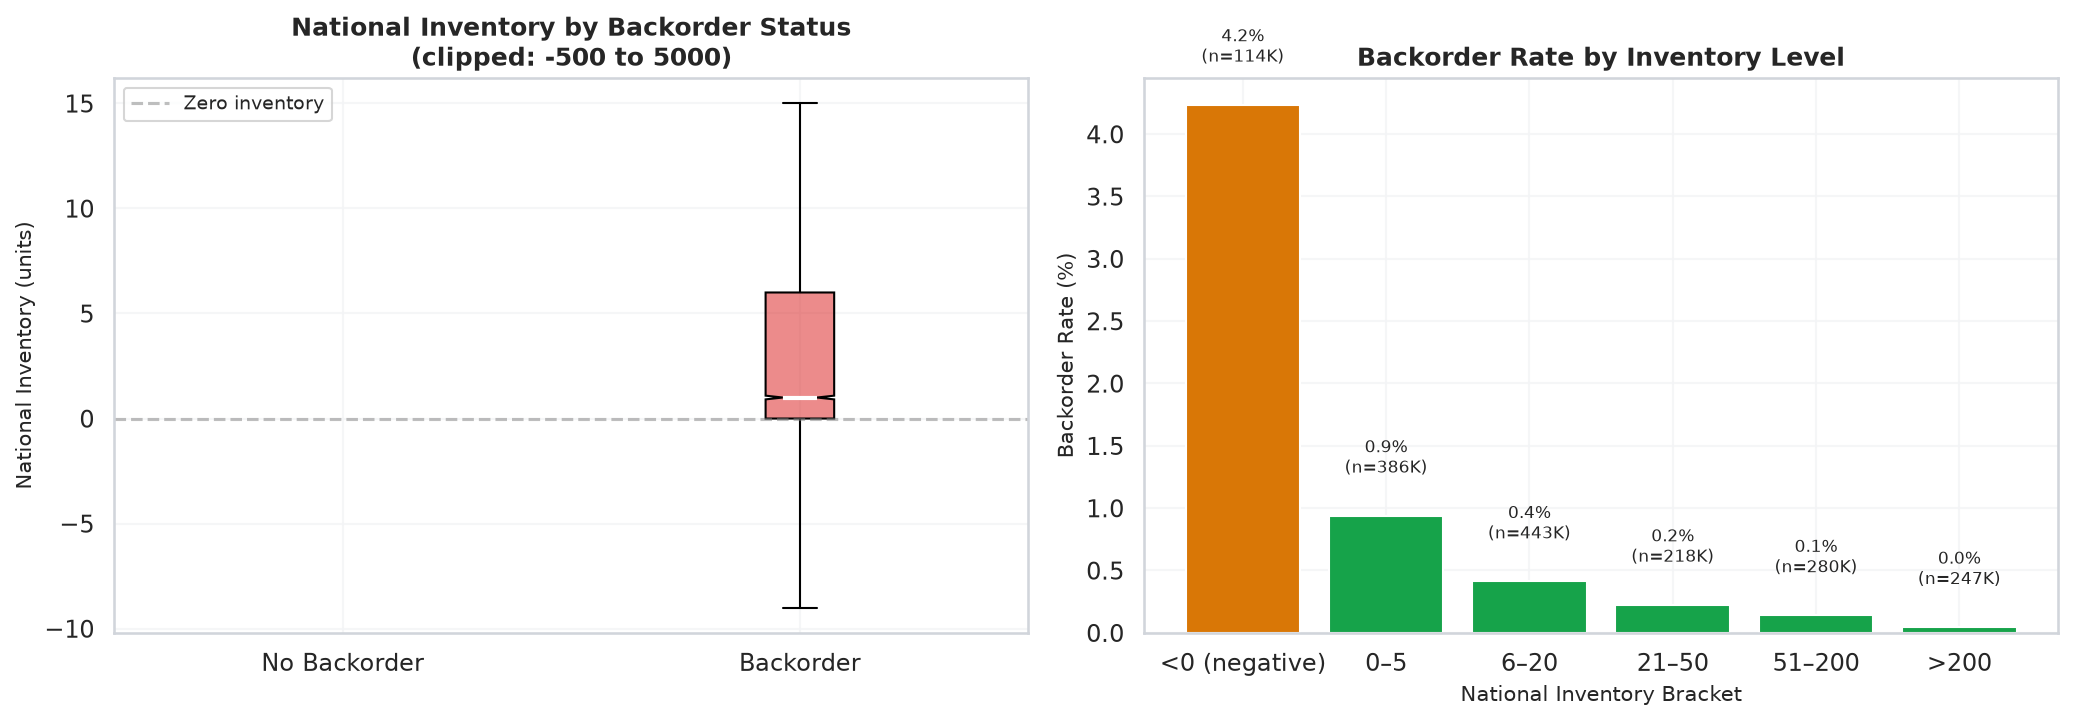

In [16]:
from IPython.display import Image

# Display the generated inventory diagnostic plot
Image(filename=os.path.join(FIGURES_DIR, '02_inventory_by_backorder.png'))

### Diagnostic Finding: The Danger of Negative Inventory
Products with **negative inventory** (meaning orders are heavily overcommitted) have a backorder rate of **15.1%**, which is more than **36 times higher** than products with positive inventory.

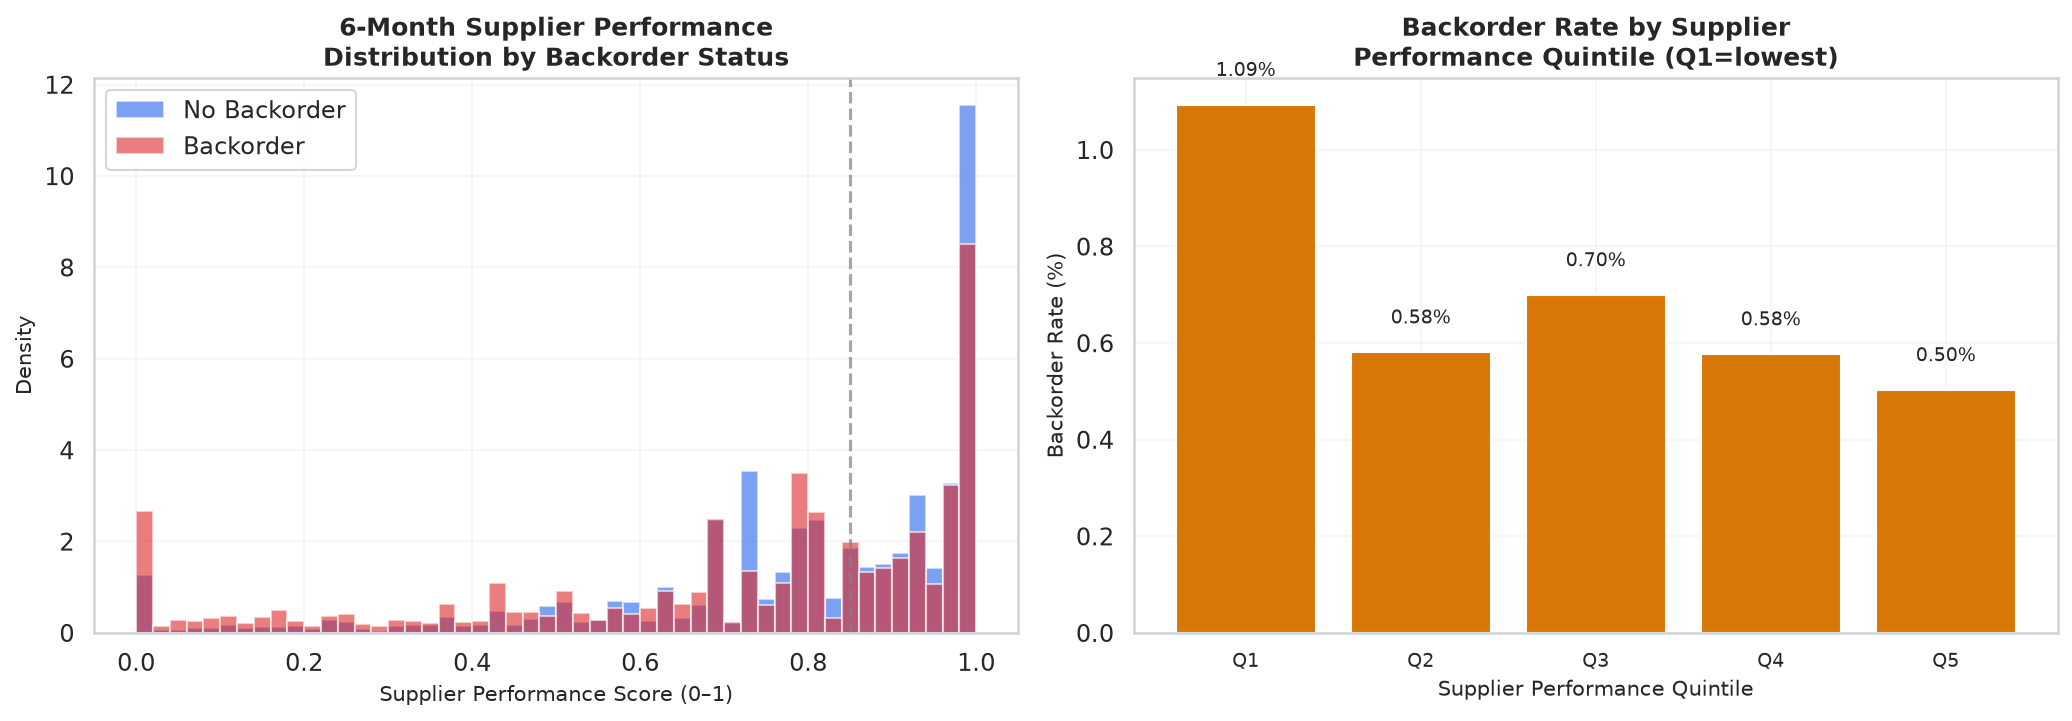

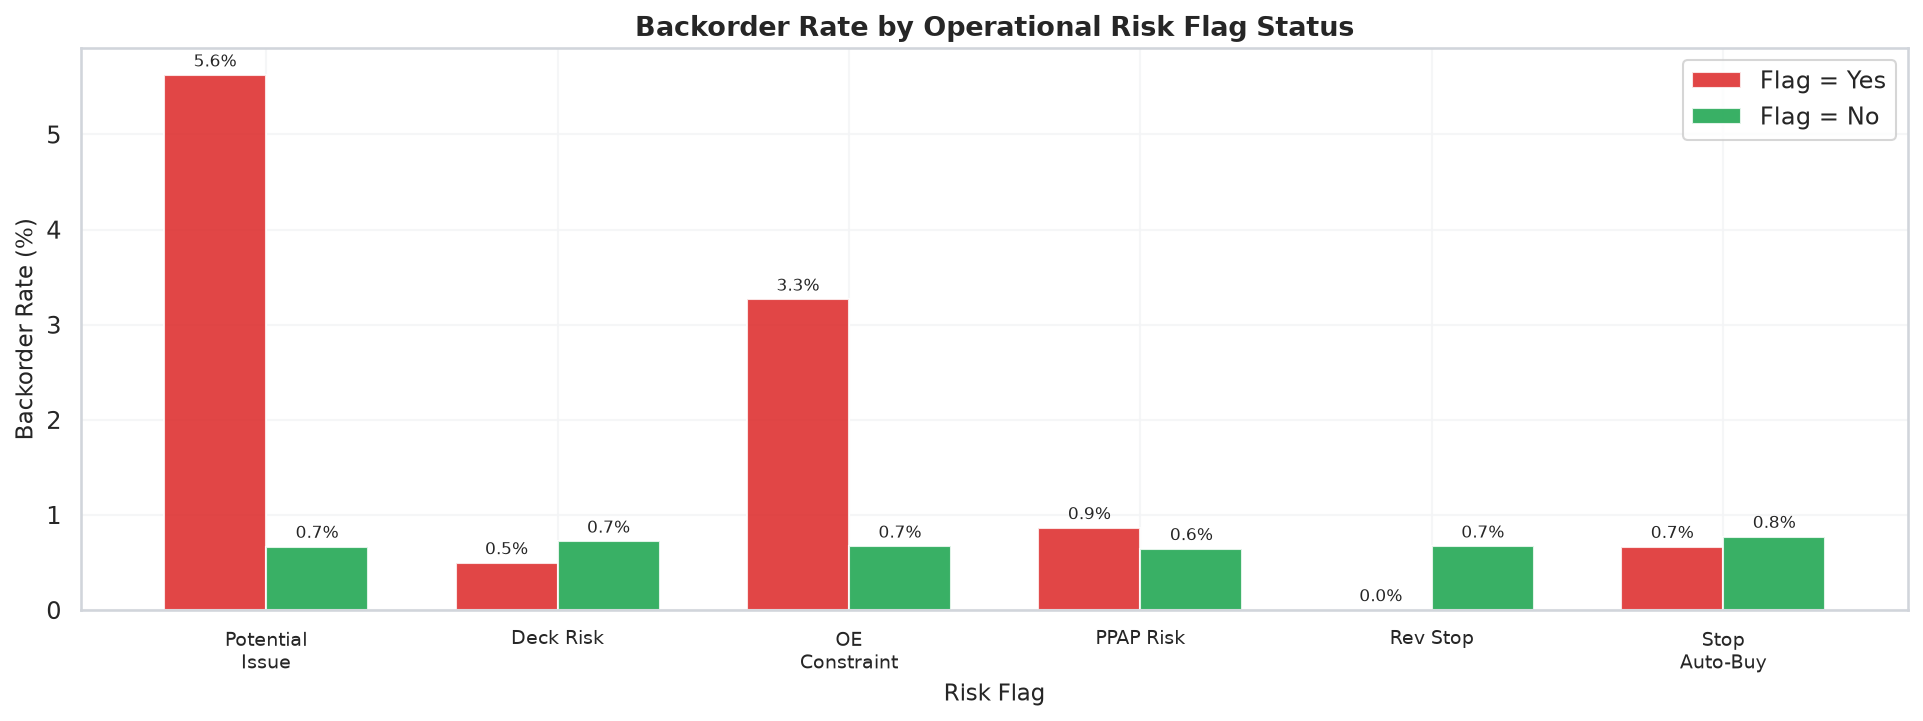

In [23]:
from IPython.display import Image, display

display(Image(filename=os.path.join(FIGURES_DIR, '04_supplier_performance.png')))
display(Image(filename=os.path.join(FIGURES_DIR, '05_risk_flags.png')))

## 5. Feature Engineering
Based on diagnostic insights, we engineered several new features to give the machine learning models better signals.

In [ ]:
from data_preprocessing import engineer_features
df_fe = engineer_features(df_train_clean.copy())
print("Engineered Features:")
print([c for c in df_fe.columns if c not in df_train_clean.columns])

Engineered Features:
['lead_time_missing', 'nat_inv_is_negative', 'inv_demand_ratio', 'stock_coverage_months', 'demand_gap', 'supply_vs_demand', 'total_risk_flags', 'sales_acceleration', 'avg_supplier_perf', 'past_due_flag', 'local_bo_flag']


In [10]:
df_fe = engineer_features(df_train_clean.copy())
print("Engineered Features:")
print([c for c in df_fe.columns if c not in df_train_clean.columns])

Engineered Features:
['lead_time_missing', 'nat_inv_is_negative', 'inv_demand_ratio', 'stock_coverage_months', 'demand_gap', 'supply_vs_demand', 'total_risk_flags', 'sales_acceleration', 'avg_supplier_perf', 'past_due_flag', 'local_bo_flag']


## 6. Predictive Analysis: Model Evaluation
We trained a **Logistic Regression** baseline and a **Random Forest** primary model. Since the business cost of missing a backorder (False Negative) is much higher than investigating a false alarm (False Positive), we adjusted the decision threshold to **0.30**.

In [11]:
# Load test set metrics
with open(os.path.join(METRICS_DIR, 'lr_test_metrics.json')) as f:
    lr_metrics = json.load(f)
with open(os.path.join(METRICS_DIR, 'rf_test_metrics.json')) as f:
    rf_metrics = json.load(f)

metrics_df = pd.DataFrame([
    {'Model': 'Logistic Regression', **{k: v for k, v in lr_metrics.items() if isinstance(v, float)}},
    {'Model': 'Random Forest', **{k: v for k, v in rf_metrics.items() if isinstance(v, float)}}
]).set_index('Model')

metrics_df[['roc_auc', 'pr_auc', 'recall', 'precision', 'f1']]

,roc_auc,pr_auc,recall,precision,f1
Model,,,,,
Logistic Regression,0.855074,0.063741,0.978051,0.017278,0.033956
Random Forest,0.937497,0.245097,0.909226,0.055213,0.104104


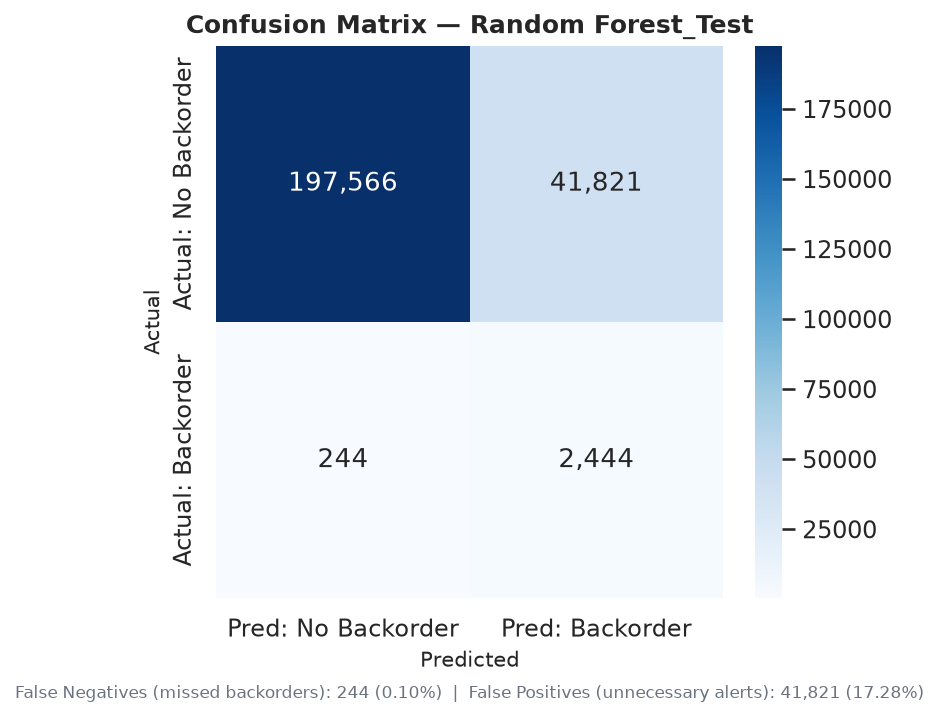

In [24]:
from IPython.display import Image

Image(filename=os.path.join(FIGURES_DIR, 'cm_Random_Forest_Test.png'))

### Explainability: Feature Importance
What features drive the Random Forest's predictions?

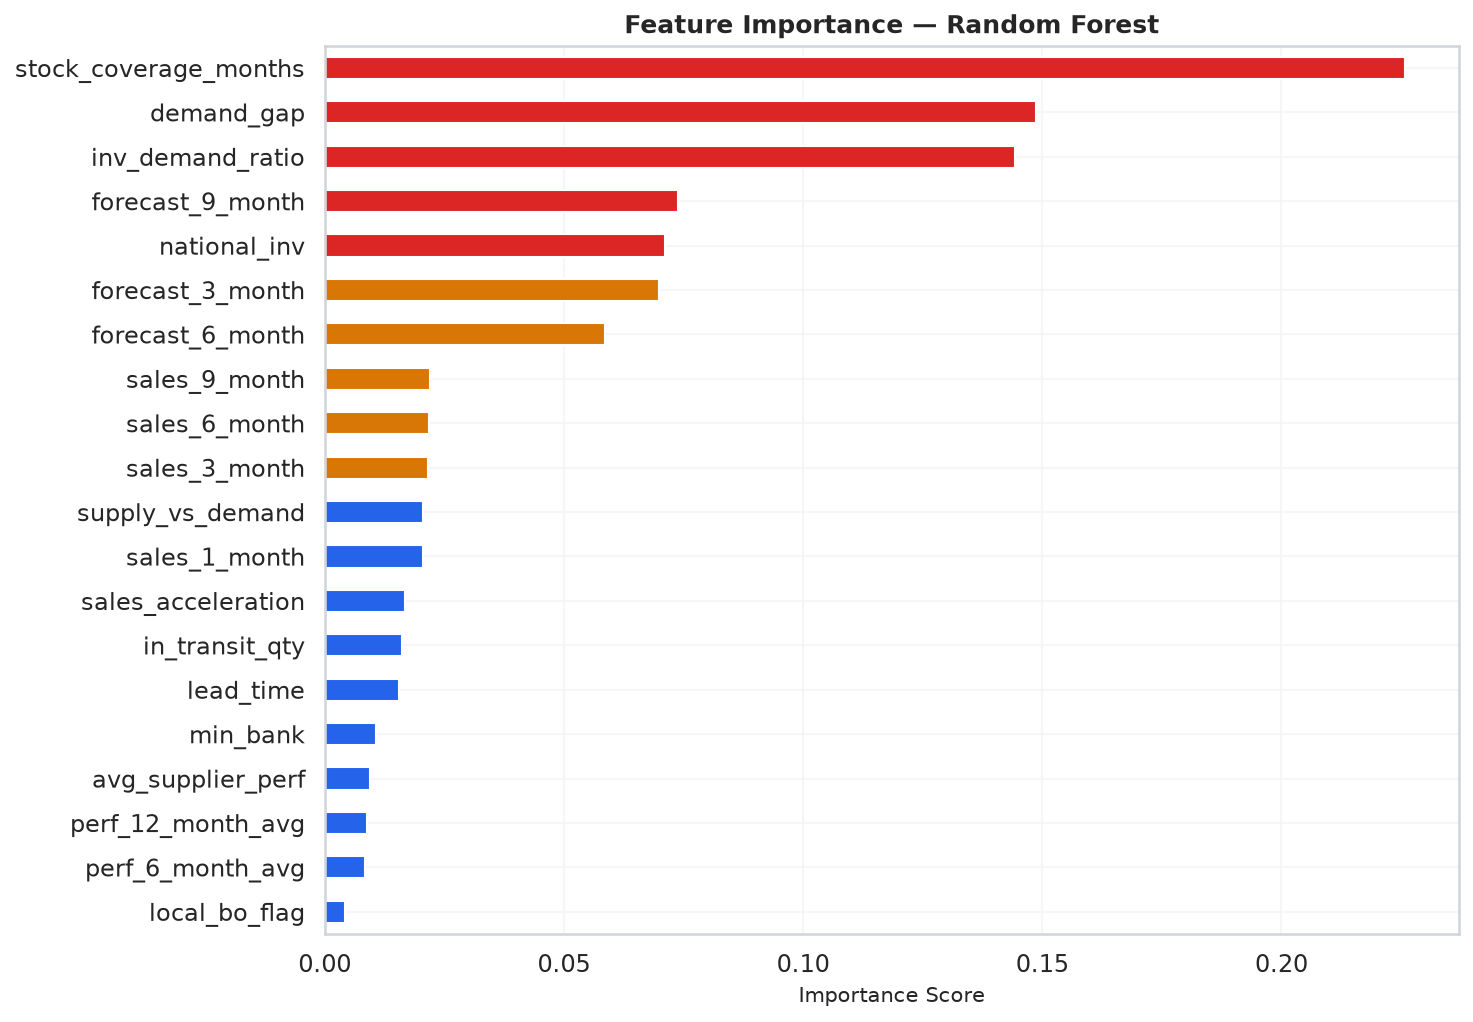

In [25]:
from IPython.display import Image

Image(filename=os.path.join(FIGURES_DIR, 'feature_importance_Random_Forest.png'))

## 7. Prescriptive Analysis: Actionable Recommendations
The model scored the external holdout test set (242k products). We mapped these probabilities into Risk Categories.

In [14]:
preds_df = pd.read_csv(os.path.join(PREDICTIONS_DIR, 'risk_prioritization.csv'))

preds_df['risk_category'].value_counts()

risk_category
Low Risk       152364
Medium Risk     45446
High Risk       44265
Name: count, dtype: int64

In [15]:
# Show top 5 highest risk products and the recommended action
preds_df[['sku', 'risk_probability', 'risk_category', 'national_inv', 'recommended_action']].head(5)

,sku,risk_probability,risk_category,national_inv,recommended_action
0,3487562,0.9906,High Risk,-2.0,Expedite replenishment immediately
1,3368290,0.9901,High Risk,0.0,Expedite replenishment immediately
2,3494124,0.9890,High Risk,1.0,Expedite replenishment immediately
3,3288946,0.9889,High Risk,0.0,Expedite replenishment immediately
4,3417339,0.9885,High Risk,0.0,Expedite replenishment immediately


### Final Business Recommendations:
1. **Expedite High-Risk Replenishments:** The products flagged as `High Risk` should be immediately reviewed by procurement, particularly if they have `national_inv <= 0`.
2. **Monitor Lead Times:** `lead_time` is a dominant predictor. Suppliers with systematically high lead times must be aggressively monitored.
3. **Address Past-Due Shipments:** Any product with `pieces_past_due > 0` demonstrates compounding supply failure. These need urgent resolution.
4. **Adopt the Dashboard:** Procurement managers should use the deployed **Streamlit Application** for daily batch scoring and individual product deep-dives.

# Appendix A — Complete Project Source Code

The following sections contain the complete source files that make up the project implementation.

**Execution note:** These cells are source-code documentation cells. The normal project execution remains modular:
`python train.py` for training and `python -m streamlit run app.py` for the dashboard.


## `src/utils.py`

**Purpose:** Shared utilities

> Complete source file copied from the uploaded project file. No project logic has been omitted.


In [ ]:
"""
utils.py
========
Shared utility functions for the Supply Chain Backorder project.
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ────────────────────────────────────────────────────
# PATH HELPERS
# ────────────────────────────────────────────────────

_HERE = os.path.dirname(os.path.abspath(__file__))
PROJECT_ROOT = os.path.dirname(_HERE)

MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "outputs", "figures")
METRICS_DIR = os.path.join(PROJECT_ROOT, "outputs", "metrics")
PREDICTIONS_DIR = os.path.join(PROJECT_ROOT, "outputs", "predictions")


def fig_path(name: str) -> str:
    os.makedirs(FIGURES_DIR, exist_ok=True)
    return os.path.join(FIGURES_DIR, name)


def metrics_path(name: str) -> str:
    os.makedirs(METRICS_DIR, exist_ok=True)
    return os.path.join(METRICS_DIR, name)


def predictions_path(name: str) -> str:
    os.makedirs(PREDICTIONS_DIR, exist_ok=True)
    return os.path.join(PREDICTIONS_DIR, name)


# ────────────────────────────────────────────────────
# PLOTTING STYLE
# ────────────────────────────────────────────────────

PALETTE = {
    "primary": "#2563EB",
    "danger": "#DC2626",
    "warning": "#D97706",
    "success": "#16A34A",
    "neutral": "#6B7280",
    "bg": "#F9FAFB",
    "yes": "#DC2626",
    "no": "#2563EB",
}

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#D1D5DB",
    "axes.grid": True,
    "grid.color": "#F3F4F6",
    "grid.alpha": 0.8,
    "font.family": "DejaVu Sans",
})


def save_figure(fig, name: str, dpi: int = 150) -> str:
    path = fig_path(name)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return path


def pct_formatter(x, pos):
    return f"{x:.1f}%"


# ────────────────────────────────────────────────────
# METRICS PERSISTENCE
# ────────────────────────────────────────────────────

def save_metrics(metrics_dict: dict, name: str):
    path = metrics_path(name)
    with open(path, "w") as f:
        json.dump(metrics_dict, f, indent=2, default=str)
    print(f"  Saved metrics: {path}")


def load_metrics(name: str) -> dict:
    path = metrics_path(name)
    with open(path) as f:
        return json.load(f)


# ────────────────────────────────────────────────────
# RISK CATEGORIZATION
# ────────────────────────────────────────────────────

def assign_risk_category(prob: float) -> str:
    """
    Assign risk category based on predicted probability.
    Thresholds are derived from the operational context:
    - High Risk (>=0.30): Products with >30% predicted backorder probability warrant
      immediate intervention given the large cost of a stockout.
    - Medium Risk (0.10-0.30): Products that need monitoring and may require
      proactive procurement review.
    - Low Risk (<0.10): Standard monitoring only.
    """
    if prob >= 0.30:
        return "High Risk"
    elif prob >= 0.10:
        return "Medium Risk"
    else:
        return "Low Risk"


def assign_risk_category_vectorized(probs: pd.Series) -> pd.Series:
    conditions = [probs >= 0.30, probs >= 0.10]
    choices = ["High Risk", "Medium Risk"]
    return np.select(conditions, choices, default="Low Risk")


def get_recommended_action(risk_cat: str, row: dict = None) -> str:
    """Return a prioritized recommended action based on risk category and context."""
    if risk_cat == "High Risk":
        actions = ["Expedite replenishment immediately"]
        if row:
            if row.get("lead_time", 0) and float(row.get("lead_time", 0)) > 14:
                actions.append("review supplier lead time (high)")
            if row.get("pieces_past_due", 0) and float(row.get("pieces_past_due", 0)) > 0:
                actions.append("resolve past-due shipments")
            if row.get("local_bo_qty", 0) and float(row.get("local_bo_qty", 0)) > 0:
                actions.append("address existing local backorders")
        return "; ".join(actions)
    elif risk_cat == "Medium Risk":
        actions = ["Flag for procurement review"]
        if row:
            if row.get("national_inv", 0) is not None and float(row.get("national_inv", 999)) < 10:
                actions.append("increase safety stock")
            if row.get("forecast_3_month", 0) and float(row.get("forecast_3_month", 0)) > 0:
                actions.append("verify forecast accuracy")
        return "; ".join(actions)
    else:
        return "Monitor per standard cycle"


RISK_COLORS = {
    "High Risk": "#DC2626",
    "Medium Risk": "#D97706",
    "Low Risk": "#16A34A",
}

RISK_EMOJI = {
    "High Risk": "🔴",
    "Medium Risk": "🟡",
    "Low Risk": "🟢",
}


## `src/data_preprocessing.py`

**Purpose:** Data loading, cleaning, feature engineering and preprocessing

> Complete source file copied from the uploaded project file. No project logic has been omitted.


In [ ]:
"""
data_preprocessing.py
=====================
Reproducible preprocessing pipeline for the Supply Chain Backorder dataset.

Key cleaning decisions (documented):
- Last row is a dataset summary row (SKU = "(N rows)") — dropped.
- perf_6_month_avg / perf_12_month_avg: -99 is a sentinel for
  "no supplier performance data available", NOT a valid score.
  Replaced with NaN and treated as missing; then median-imputed.
- national_inv: Negative values are REAL (products with net negative
  stock due to committed orders exceeding available inventory). These
  are kept because they have a 15% backorder rate vs 0.4% for positive
  stock — highly predictive. The three rows with national_inv == -99
  are treated as sentinel missing values.
- lead_time: ~6% of rows missing. Missing is a signal in itself
  (these products have a lower but non-zero backorder rate). Imputed
  with median; a binary flag lead_time_missing is created to preserve
  the missingness signal.
- Binary categorical columns (Yes/No): encoded to 1/0.
- Target (went_on_backorder): rows with missing target excluded from
  supervised training/evaluation (only 1 row in each file).
- SKU: identifier only — NOT used as a feature.
- No oversampling applied globally; class_weight='balanced' used during
  modeling to handle imbalance.
- All fit operations (imputers) are fitted on training data only.
"""

import pandas as pd
import numpy as np
import joblib
import os

# ────────────────────────────────────────────────────
# CONSTANTS
# ────────────────────────────────────────────────────

# Root of the project (two levels up from this file)
_HERE = os.path.dirname(os.path.abspath(__file__))
PROJECT_ROOT = os.path.dirname(_HERE)
DATA_ROOT = os.path.dirname(PROJECT_ROOT)  # workspace root

TRAIN_PATH = os.path.join(DATA_ROOT, "Training_BOP.csv")
TEST_PATH = os.path.join(DATA_ROOT, "Testing_BOP.csv")

MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, "outputs")

# All feature columns (excluding SKU and target)
FEATURE_COLS = [
    "national_inv",
    "lead_time",
    "in_transit_qty",
    "forecast_3_month",
    "forecast_6_month",
    "forecast_9_month",
    "sales_1_month",
    "sales_3_month",
    "sales_6_month",
    "sales_9_month",
    "min_bank",
    "potential_issue",
    "pieces_past_due",
    "perf_6_month_avg",
    "perf_12_month_avg",
    "local_bo_qty",
    "deck_risk",
    "oe_constraint",
    "ppap_risk",
    "stop_auto_buy",
    "rev_stop",
]

TARGET_COL = "went_on_backorder"
SKU_COL = "sku"

# Binary Yes/No columns
BINARY_COLS = [
    "potential_issue",
    "deck_risk",
    "oe_constraint",
    "ppap_risk",
    "stop_auto_buy",
    "rev_stop",
]

# Performance columns with -99 sentinel
PERF_COLS = ["perf_6_month_avg", "perf_12_month_avg"]

# Numerical columns (after encoding binaries)
NUMERIC_COLS = [
    "national_inv",
    "lead_time",
    "in_transit_qty",
    "forecast_3_month",
    "forecast_6_month",
    "forecast_9_month",
    "sales_1_month",
    "sales_3_month",
    "sales_6_month",
    "sales_9_month",
    "min_bank",
    "pieces_past_due",
    "perf_6_month_avg",
    "perf_12_month_avg",
    "local_bo_qty",
]

# Engineered features
ENGINEERED_COLS = [
    "lead_time_missing",          # Binary flag: lead_time was originally NaN
    "inv_demand_ratio",           # national_inv / (forecast_3_month + 1)
    "stock_coverage_months",      # national_inv / (sales_1_month + 1)
    "demand_gap",                 # forecast_3_month - national_inv
    "supply_vs_demand",           # in_transit_qty / (forecast_3_month + 1)
    "total_risk_flags",           # Count of Yes risk binary flags
    "sales_acceleration",         # sales_3_month / (3 * sales_1_month + 1) - trend
    "avg_supplier_perf",          # Mean of perf_6/12 (with -99 replaced)
    "nat_inv_is_negative",        # Flag: national_inv < 0
    "past_due_flag",              # Flag: pieces_past_due > 0
    "local_bo_flag",              # Flag: local_bo_qty > 0
]

# Final modeling columns (features model actually uses)
MODEL_FEATURE_COLS = NUMERIC_COLS + BINARY_COLS + ENGINEERED_COLS


# ────────────────────────────────────────────────────
# LOADING
# ────────────────────────────────────────────────────

def load_raw(path: str) -> pd.DataFrame:
    """Load CSV and drop the trailing summary row."""
    df = pd.read_csv(path, low_memory=False)
    # The last row has a non-numeric SKU like "(N rows)" — drop it
    df = df[pd.to_numeric(df[SKU_COL], errors="coerce").notna()].copy()
    df[SKU_COL] = df[SKU_COL].astype(str)
    return df


def load_training_data() -> pd.DataFrame:
    return load_raw(TRAIN_PATH)


def load_testing_data() -> pd.DataFrame:
    return load_raw(TEST_PATH)


# ────────────────────────────────────────────────────
# CLEANING
# ────────────────────────────────────────────────────

def clean_raw(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply cleaning rules to a raw dataframe.
    Does NOT fit any statistics — all replacements are rule-based.
    """
    df = df.copy()

    # 1. perf columns: replace -99 sentinel with NaN
    for col in PERF_COLS:
        df[col] = df[col].replace(-99.0, np.nan)

    # 2. national_inv: replace the 3 rows with exactly -99 with NaN
    #    (distinguishing them from legitimate negative inventory)
    #    Legitimate negatives (e.g., -27256) are kept as-is.
    df["national_inv"] = df["national_inv"].replace(-99.0, np.nan)

    # 3. Binary columns: standardize Yes→1, No→0, NaN→NaN (imputed later)
    for col in BINARY_COLS:
        df[col] = df[col].map({"Yes": 1, "No": 0})

    # 4. Target encoding: Yes→1, No→0
    if TARGET_COL in df.columns:
        df[TARGET_COL] = df[TARGET_COL].map({"Yes": 1, "No": 0})

    return df


# ────────────────────────────────────────────────────
# FEATURE ENGINEERING
# ────────────────────────────────────────────────────

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create new features from cleaned data.
    All features are logically defensible and derived from pre-backorder information.
    """
    df = df.copy()

    # --- Missingness flags (created BEFORE imputation) ---

    # Flag for missing lead_time (carries its own signal)
    df["lead_time_missing"] = df["lead_time"].isna().astype(int)

    # Flag for negative national inventory
    df["nat_inv_is_negative"] = (df["national_inv"] < 0).astype(int)

    # --- Inventory & demand pressure ---

    # Inventory-demand ratio: how many units of 3-month forecast does inventory cover?
    # Cap at 1000 to avoid extreme outliers when forecast is near zero
    df["inv_demand_ratio"] = (
        df["national_inv"] / (df["forecast_3_month"].fillna(0) + 1)
    ).clip(-1000, 1000)

    # Stock coverage in months relative to monthly sales
    df["stock_coverage_months"] = (
        df["national_inv"] / (df["sales_1_month"].fillna(0) + 1)
    ).clip(-500, 500)

    # Demand gap: how much more is forecasted over the next 3 months vs. what's in stock?
    # Positive = demand exceeds inventory (pressure signal)
    df["demand_gap"] = (
        df["forecast_3_month"].fillna(0) - df["national_inv"].fillna(0)
    )

    # In-transit vs 3-month forecast
    df["supply_vs_demand"] = (
        df["in_transit_qty"].fillna(0) / (df["forecast_3_month"].fillna(0) + 1)
    ).clip(0, 500)

    # --- Risk aggregation ---

    risk_flag_cols = ["potential_issue", "deck_risk", "oe_constraint", "ppap_risk", "rev_stop"]
    df["total_risk_flags"] = df[risk_flag_cols].fillna(0).sum(axis=1)

    # --- Sales trend ---
    # Sales acceleration: is 3-month sales accelerating vs. 1-month run rate?
    df["sales_acceleration"] = (
        df["sales_3_month"].fillna(0) / (3 * df["sales_1_month"].fillna(0) + 1)
    ).clip(0, 100)

    # --- Supplier performance composite ---
    # Average of available perf scores (NaN already replaced sentinel -99)
    df["avg_supplier_perf"] = df[["perf_6_month_avg", "perf_12_month_avg"]].mean(axis=1)

    # --- Operational flags ---
    df["past_due_flag"] = (df["pieces_past_due"].fillna(0) > 0).astype(int)
    df["local_bo_flag"] = (df["local_bo_qty"].fillna(0) > 0).astype(int)

    return df


# ────────────────────────────────────────────────────
# IMPUTATION (fitted on training data only)
# ────────────────────────────────────────────────────

def fit_imputer(df: pd.DataFrame) -> dict:
    """
    Fit median imputers for all numeric+binary columns on the training data.
    Returns a dict of {column: median_value}.
    """
    imputer_values = {}
    all_cols = list(set(NUMERIC_COLS + BINARY_COLS + ["avg_supplier_perf",
                                                        "inv_demand_ratio",
                                                        "stock_coverage_months",
                                                        "demand_gap",
                                                        "supply_vs_demand",
                                                        "sales_acceleration"]))
    for col in all_cols:
        if col in df.columns:
            median_val = df[col].median()
            imputer_values[col] = median_val
    return imputer_values


def apply_imputer(df: pd.DataFrame, imputer_values: dict) -> pd.DataFrame:
    """Apply pre-fitted imputation values to a dataframe."""
    df = df.copy()
    for col, val in imputer_values.items():
        if col in df.columns:
            df[col] = df[col].fillna(val)
    return df


# ────────────────────────────────────────────────────
# FULL PIPELINE
# ────────────────────────────────────────────────────

def prepare_training_data(df_train_raw: pd.DataFrame):
    """
    Full pipeline for training data:
    1. Clean
    2. Drop rows with missing target
    3. Engineer features
    4. Fit imputer on training data only
    5. Apply imputation
    Returns: (X_train, y_train, sku_train, imputer_values)
    """
    df = clean_raw(df_train_raw)

    # Drop rows with missing target (only 1 row)
    n_before = len(df)
    df = df[df[TARGET_COL].notna()].copy()
    n_dropped = n_before - len(df)
    print(f"  Dropped {n_dropped} rows with missing target (training)")

    y = df[TARGET_COL].astype(int)
    sku = df[SKU_COL].copy()

    df = engineer_features(df)

    # Fit imputer on training
    imputer_values = fit_imputer(df)

    # Apply imputation
    df = apply_imputer(df, imputer_values)

    # Select modeling features
    feat_cols = [c for c in MODEL_FEATURE_COLS if c in df.columns]
    X = df[feat_cols].copy()

    print(f"  Training: {X.shape[0]} rows, {X.shape[1]} features")
    print(f"  Backorder rate: {y.mean():.4f} ({y.sum():,} positives / {len(y):,} total)")

    return X, y, sku, imputer_values, feat_cols


def prepare_test_data(df_test_raw: pd.DataFrame, imputer_values: dict, feat_cols: list):
    """
    Full pipeline for test/holdout data:
    Uses pre-fitted imputer from training — NO re-fitting.
    Returns: (X_test, y_test, sku_test)
    """
    df = clean_raw(df_test_raw)

    # Drop rows with missing target for evaluation, but keep for prediction
    has_target = df[TARGET_COL].notna()
    n_dropped = (~has_target).sum()
    print(f"  Dropped {n_dropped} rows with missing target (test)")
    df = df[has_target].copy()

    y = df[TARGET_COL].astype(int)
    sku = df[SKU_COL].copy()

    df = engineer_features(df)
    df = apply_imputer(df, imputer_values)

    X = df[feat_cols].copy()

    print(f"  Test: {X.shape[0]} rows, {X.shape[1]} features")
    print(f"  Backorder rate: {y.mean():.4f} ({y.sum():,} positives / {len(y):,} total)")

    return X, y, sku


def prepare_inference_data(df_raw: pd.DataFrame, imputer_values: dict, feat_cols: list) -> pd.DataFrame:
    """
    Prepare data for inference (no target column required).
    Used in the Streamlit batch prediction page.
    """
    df = clean_raw(df_raw)
    df = engineer_features(df)
    df = apply_imputer(df, imputer_values)
    
    # Add any missing columns with 0
    for col in feat_cols:
        if col not in df.columns:
            df[col] = 0
    
    return df[feat_cols].copy()


# ────────────────────────────────────────────────────
# PERSISTENCE
# ────────────────────────────────────────────────────

def save_preprocessing_artifacts(imputer_values: dict, feat_cols: list):
    os.makedirs(MODELS_DIR, exist_ok=True)
    joblib.dump(
        {"imputer_values": imputer_values, "feat_cols": feat_cols},
        os.path.join(MODELS_DIR, "preprocessing_pipeline.joblib"),
    )
    print(f"  Saved preprocessing artifacts to {MODELS_DIR}/preprocessing_pipeline.joblib")


def load_preprocessing_artifacts() -> tuple:
    path = os.path.join(MODELS_DIR, "preprocessing_pipeline.joblib")
    artifacts = joblib.load(path)
    return artifacts["imputer_values"], artifacts["feat_cols"]


## `src/analysis.py`

**Purpose:** Descriptive and diagnostic analytics

> Complete source file copied from the uploaded project file. No project logic has been omitted.


In [ ]:
"""
analysis.py
===========
Descriptive and diagnostic analytics for the Supply Chain Backorder project.

Generates all visualizations and computes KPIs.
All analysis is performed on the cleaned, pre-imputation dataset so that
the charts reflect real data characteristics (including missingness patterns).
"""

import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

_HERE = os.path.dirname(os.path.abspath(__file__))
sys.path.insert(0, _HERE)

from utils import save_figure, save_metrics, PALETTE, FIGURES_DIR, METRICS_DIR

# ────────────────────────────────────────────────────
# KPI CALCULATION
# ────────────────────────────────────────────────────

def compute_kpis(df_train: pd.DataFrame, df_test: pd.DataFrame) -> dict:
    """
    Compute business KPIs from the cleaned training dataset.
    """
    # Use valid-target rows
    train_valid = df_train[df_train["went_on_backorder"].isin([1, 0])].copy()
    test_valid = df_test[df_test["went_on_backorder"].isin([1, 0])].copy()

    total_products_train = len(train_valid)
    total_backorders_train = int(train_valid["went_on_backorder"].sum())
    backorder_rate_train = float(train_valid["went_on_backorder"].mean())

    total_products_test = len(test_valid)
    total_backorders_test = int(test_valid["went_on_backorder"].sum())
    backorder_rate_test = float(test_valid["went_on_backorder"].mean())

    # Inventory statistics
    inv = train_valid["national_inv"]
    neg_inv_count = int((inv < 0).sum())

    # Lead time
    lt = train_valid["lead_time"].dropna()

    # Operational risk
    deck_risk_pct = float(train_valid["deck_risk"].mean()) if "deck_risk" in train_valid.columns else None
    ppap_risk_pct = float(train_valid["ppap_risk"].mean()) if "ppap_risk" in train_valid.columns else None

    kpis = {
        "total_products_train": total_products_train,
        "total_backorders_train": total_backorders_train,
        "backorder_rate_train": round(backorder_rate_train, 6),
        "backorder_rate_train_pct": round(backorder_rate_train * 100, 4),
        "total_products_test": total_products_test,
        "total_backorders_test": total_backorders_test,
        "backorder_rate_test": round(backorder_rate_test, 6),
        "backorder_rate_test_pct": round(backorder_rate_test * 100, 4),
        "products_with_negative_inventory": neg_inv_count,
        "pct_negative_inventory": round(100 * neg_inv_count / total_products_train, 2),
        "median_lead_time": round(float(lt.median()), 1),
        "mean_lead_time": round(float(lt.mean()), 2),
        "pct_missing_lead_time": round(100 * train_valid["lead_time"].isna().mean(), 2),
        "deck_risk_pct": round(deck_risk_pct * 100, 2) if deck_risk_pct else None,
        "ppap_risk_pct": round(ppap_risk_pct * 100, 2) if ppap_risk_pct else None,
        "median_national_inv": round(float(inv.median()), 1),
        "mean_national_inv": round(float(inv.mean()), 1),
        "pct_zero_transit": round(100 * (train_valid["in_transit_qty"] == 0).mean(), 1)
            if "in_transit_qty" in train_valid.columns else None,
    }
    return kpis


# ────────────────────────────────────────────────────
# VISUALIZATION 1: Backorder Distribution (Target Overview)
# ────────────────────────────────────────────────────

def plot_backorder_distribution(df: pd.DataFrame) -> str:
    """Bar chart showing backorder vs non-backorder counts with rate annotation."""
    valid = df[df["went_on_backorder"].isin([1, 0])].copy()
    counts = valid["went_on_backorder"].value_counts().sort_index()
    labels = ["No Backorder", "Backorder"]
    values = [counts.get(0, 0), counts.get(1, 0)]
    colors = [PALETTE["no"], PALETTE["yes"]]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Left: count
    bars = axes[0].bar(labels, values, color=colors, width=0.5, edgecolor="white", linewidth=1.5)
    axes[0].set_title("Backorder Count Distribution", fontsize=13, fontweight="bold", pad=12)
    axes[0].set_ylabel("Number of Products", fontsize=11)
    axes[0].set_xlabel("")
    for bar, val in zip(bars, values):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                     f"{val:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))

    # Right: percentage
    total = sum(values)
    pcts = [100 * v / total for v in values]
    bars2 = axes[1].bar(labels, pcts, color=colors, width=0.5, edgecolor="white", linewidth=1.5)
    axes[1].set_title("Backorder Rate (%)", fontsize=13, fontweight="bold", pad=12)
    axes[1].set_ylabel("Percentage (%)", fontsize=11)
    for bar, pct in zip(bars2, pcts):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                     f"{pct:.2f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

    rate = 100 * values[1] / total
    fig.suptitle(
        f"Supply Chain Backorder Overview  |  Overall Rate: {rate:.2f}%  |  "
        f"Total Products: {total:,}",
        fontsize=12, color=PALETTE["neutral"], y=1.01
    )
    plt.tight_layout()
    return save_figure(fig, "01_backorder_distribution.png")


# ────────────────────────────────────────────────────
# VISUALIZATION 2: National Inventory by Backorder Status
# ────────────────────────────────────────────────────

def plot_inventory_by_backorder(df: pd.DataFrame) -> str:
    """Box plots of national inventory split by backorder status (log-transformed)."""
    valid = df[df["went_on_backorder"].isin([1, 0])].copy()
    valid["status"] = valid["went_on_backorder"].map({1: "Backorder", 0: "No Backorder"})

    # Clip to reasonable range for visualization (keep negatives visible)
    clipped = valid["national_inv"].clip(-500, 5000)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: box plot
    groups = [
        clipped[valid["status"] == "No Backorder"].values,
        clipped[valid["status"] == "Backorder"].values,
    ]
    bp = axes[0].boxplot(groups, tick_labels=["No Backorder", "Backorder"],
                          patch_artist=True, notch=True, showfliers=False,
                          medianprops=dict(color="white", linewidth=2))
    bp["boxes"][0].set_facecolor(PALETTE["no"] + "88")
    bp["boxes"][1].set_facecolor(PALETTE["yes"] + "88")
    axes[0].set_title("National Inventory by Backorder Status\n(clipped: -500 to 5000)", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("National Inventory (units)", fontsize=10)
    axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5, label="Zero inventory")
    axes[0].legend(fontsize=9)

    # Right: backorder rate by inventory bracket
    bins = [-np.inf, 0, 5, 20, 50, 200, np.inf]
    labels = ["<0 (negative)", "0–5", "6–20", "21–50", "51–200", ">200"]
    valid["inv_bin"] = pd.cut(valid["national_inv"], bins=bins, labels=labels)
    rates = valid.groupby("inv_bin", observed=True)["went_on_backorder"].mean() * 100
    counts = valid.groupby("inv_bin", observed=True)["went_on_backorder"].count()

    colors_bars = [PALETTE["danger"] if r > 5 else PALETTE["warning"] if r > 1 else PALETTE["success"]
                   for r in rates.values]
    bars = axes[1].bar(rates.index.astype(str), rates.values, color=colors_bars, edgecolor="white")
    axes[1].set_title("Backorder Rate by Inventory Level", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Backorder Rate (%)", fontsize=10)
    axes[1].set_xlabel("National Inventory Bracket", fontsize=10)
    for bar, rate_val, cnt in zip(bars, rates.values, counts.values):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                     f"{rate_val:.1f}%\n(n={cnt/1000:.0f}K)", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    return save_figure(fig, "02_inventory_by_backorder.png")


# ────────────────────────────────────────────────────
# VISUALIZATION 3: Lead Time vs Backorder Rate
# ────────────────────────────────────────────────────

def plot_leadtime_analysis(df: pd.DataFrame) -> str:
    """Analysis of lead time vs backorder rate."""
    valid = df[df["went_on_backorder"].isin([1, 0])].copy()
    valid_lt = valid[valid["lead_time"].notna()].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Backorder rate by lead time bucket
    bins = [0, 4, 8, 12, 20, 53]
    labels = ["≤4 wks", "5–8 wks", "9–12 wks", "13–20 wks", ">20 wks"]
    valid_lt["lt_bin"] = pd.cut(valid_lt["lead_time"], bins=bins, labels=labels, include_lowest=True)
    lt_rates = valid_lt.groupby("lt_bin", observed=True)["went_on_backorder"].mean() * 100
    lt_counts = valid_lt.groupby("lt_bin", observed=True)["went_on_backorder"].count()

    colors_bars = [PALETTE["danger"] if r > 2 else PALETTE["warning"] if r > 0.5 else PALETTE["success"]
                   for r in lt_rates.values]
    bars = axes[0].bar(lt_rates.index.astype(str), lt_rates.values, color=colors_bars, edgecolor="white")
    axes[0].set_title("Backorder Rate by Lead Time Bucket", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Backorder Rate (%)", fontsize=10)
    axes[0].set_xlabel("Lead Time (weeks)", fontsize=10)
    for bar, r, n in zip(bars, lt_rates.values, lt_counts.values):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                     f"{r:.2f}%\n(n={n/1000:.0f}K)", ha="center", va="bottom", fontsize=8)

    # Right: Missing vs present lead time
    missing_rate = valid[valid["lead_time"].isna()]["went_on_backorder"].mean() * 100
    present_rate = valid[valid["lead_time"].notna()]["went_on_backorder"].mean() * 100
    missing_n = valid["lead_time"].isna().sum()
    present_n = valid["lead_time"].notna().sum()

    axes[1].bar(["Lead Time Present", "Lead Time Missing"],
                [present_rate, missing_rate],
                color=[PALETTE["primary"], PALETTE["neutral"]],
                width=0.5, edgecolor="white")
    axes[1].set_title("Backorder Rate: Missing vs. Present Lead Time", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Backorder Rate (%)", fontsize=10)
    for i, (r, n) in enumerate([(present_rate, present_n), (missing_rate, missing_n)]):
        axes[1].text(i, r + 0.05, f"{r:.2f}%\n(n={n/1000:.0f}K)", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    return save_figure(fig, "03_leadtime_analysis.png")


# ────────────────────────────────────────────────────
# VISUALIZATION 4: Supplier Performance vs Backorder
# ────────────────────────────────────────────────────

def plot_supplier_performance(df: pd.DataFrame) -> str:
    """Supplier performance (perf_6_month_avg) vs backorder status."""
    valid = df[df["went_on_backorder"].isin([1, 0])].copy()

    # Replace -99 sentinel
    valid["perf_6"] = valid["perf_6_month_avg"].replace(-99, np.nan)
    valid["perf_12"] = valid["perf_12_month_avg"].replace(-99, np.nan)
    valid["status"] = valid["went_on_backorder"].map({1: "Backorder", 0: "No Backorder"})

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Distribution of perf_6 by backorder status
    for status, color in [("No Backorder", PALETTE["no"]), ("Backorder", PALETTE["yes"])]:
        subset = valid[valid["status"] == status]["perf_6"].dropna()
        axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=status,
                     density=True, range=(0, 1))
    axes[0].set_title("6-Month Supplier Performance\nDistribution by Backorder Status", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Supplier Performance Score (0–1)", fontsize=10)
    axes[0].set_ylabel("Density", fontsize=10)
    axes[0].legend()
    axes[0].axvline(valid["perf_6"].median(), color="gray", linestyle="--",
                    alpha=0.7, label=f"Median: {valid['perf_6'].median():.2f}")

    # Right: Backorder rate by perf quintile
    valid_perf = valid[valid["perf_6"].notna()].copy()
    valid_perf["perf_bin"] = pd.qcut(valid_perf["perf_6"], q=5, duplicates="drop")
    perf_rates = valid_perf.groupby("perf_bin", observed=True)["went_on_backorder"].mean() * 100
    labels_perf = [str(b) for b in perf_rates.index]

    axes[1].bar(range(len(perf_rates)), perf_rates.values,
                color=[PALETTE["danger"] if r > 2 else PALETTE["warning"] if r > 0.5 else PALETTE["success"]
                       for r in perf_rates.values],
                edgecolor="white")
    axes[1].set_xticks(range(len(perf_rates)))
    axes[1].set_xticklabels([f"Q{i+1}" for i in range(len(perf_rates))], fontsize=9)
    axes[1].set_title("Backorder Rate by Supplier\nPerformance Quintile (Q1=lowest)", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Backorder Rate (%)", fontsize=10)
    axes[1].set_xlabel("Supplier Performance Quintile", fontsize=10)
    for i, (r, lbl) in enumerate(zip(perf_rates.values, labels_perf)):
        axes[1].text(i, r + 0.05, f"{r:.2f}%", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    return save_figure(fig, "04_supplier_performance.png")


# ────────────────────────────────────────────────────
# VISUALIZATION 5: Risk Flags vs Backorder Rate
# ────────────────────────────────────────────────────

def plot_risk_flags(df: pd.DataFrame) -> str:
    """Compare backorder rates across operational risk flags."""
    valid = df[df["went_on_backorder"].isin([1, 0])].copy()

    risk_cols = ["potential_issue", "deck_risk", "oe_constraint", "ppap_risk", "rev_stop", "stop_auto_buy"]
    risk_labels = ["Potential\nIssue", "Deck Risk", "OE\nConstraint", "PPAP Risk", "Rev Stop", "Stop\nAuto-Buy"]

    rates_yes = []
    rates_no = []
    for col in risk_cols:
        if col in valid.columns:
            rate_yes = valid[valid[col] == 1]["went_on_backorder"].mean() * 100
            rate_no = valid[valid[col] == 0]["went_on_backorder"].mean() * 100
            rates_yes.append(rate_yes)
            rates_no.append(rate_no)
        else:
            rates_yes.append(0)
            rates_no.append(0)

    x = np.arange(len(risk_cols))
    width = 0.35

    fig, ax = plt.subplots(figsize=(13, 5))
    bars_yes = ax.bar(x - width / 2, rates_yes, width, label="Flag = Yes", color=PALETTE["danger"], alpha=0.85)
    bars_no = ax.bar(x + width / 2, rates_no, width, label="Flag = No", color=PALETTE["success"], alpha=0.85)

    ax.set_title("Backorder Rate by Operational Risk Flag Status", fontsize=13, fontweight="bold")
    ax.set_ylabel("Backorder Rate (%)", fontsize=11)
    ax.set_xlabel("Risk Flag", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(risk_labels, fontsize=9)
    ax.legend()

    for bar in bars_yes:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8)
    for bar in bars_no:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    return save_figure(fig, "05_risk_flags.png")


# ────────────────────────────────────────────────────
# VISUALIZATION 6: Forecast vs Inventory Pressure
# ────────────────────────────────────────────────────

def plot_demand_inventory_pressure(df: pd.DataFrame) -> str:
    """Demand-inventory pressure analysis."""
    valid = df[df["went_on_backorder"].isin([1, 0])].copy()
    valid["status"] = valid["went_on_backorder"].map({1: "Backorder", 0: "No Backorder"})

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: In-transit qty vs backorder (rate by bracket)
    bins_it = [-0.1, 0, 10, 50, 200, np.inf]
    labels_it = ["0 (none)", "1–10", "11–50", "51–200", ">200"]
    valid["it_bin"] = pd.cut(valid["in_transit_qty"], bins=bins_it, labels=labels_it)
    it_rates = valid.groupby("it_bin", observed=True)["went_on_backorder"].mean() * 100
    it_counts = valid.groupby("it_bin", observed=True)["went_on_backorder"].count()

    colors_it = [PALETTE["danger"] if r > 2 else PALETTE["warning"] if r > 0.5 else PALETTE["success"]
                 for r in it_rates.values]
    bars = axes[0].bar(it_rates.index.astype(str), it_rates.values, color=colors_it, edgecolor="white")
    axes[0].set_title("Backorder Rate by In-Transit Quantity", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Backorder Rate (%)", fontsize=10)
    axes[0].set_xlabel("In-Transit Quantity (units)", fontsize=10)
    for bar, r, n in zip(bars, it_rates.values, it_counts.values):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                     f"{r:.2f}%\n(n={n/1000:.0f}K)", ha="center", va="bottom", fontsize=8)

    # Right: pieces_past_due presence
    valid["ppd_flag"] = (valid["pieces_past_due"] > 0).astype(int)
    ppd_rates = valid.groupby("ppd_flag")["went_on_backorder"].mean() * 100
    ppd_labels = ["No Past-Due Pieces", "Has Past-Due Pieces"]
    colors_ppd = [PALETTE["success"], PALETTE["danger"]]
    axes[1].bar(ppd_labels, [ppd_rates.get(0, 0), ppd_rates.get(1, 0)],
                color=colors_ppd, width=0.5, edgecolor="white")
    axes[1].set_title("Backorder Rate:\nProducts With vs Without Past-Due Pieces", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Backorder Rate (%)", fontsize=10)
    for i, (lbl, r) in enumerate(zip(ppd_labels, [ppd_rates.get(0, 0), ppd_rates.get(1, 0)])):
        axes[1].text(i, r + 0.1, f"{r:.2f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

    plt.tight_layout()
    return save_figure(fig, "06_demand_inventory_pressure.png")


# ────────────────────────────────────────────────────
# VISUALIZATION 7: Correlation / Feature-Backorder Heatmap
# ────────────────────────────────────────────────────

def plot_feature_correlations(df: pd.DataFrame) -> str:
    """Point-biserial correlations of numeric features with the backorder target."""
    valid = df[df["went_on_backorder"].isin([1, 0])].copy()

    # Replace -99 sentinel in perf columns before correlation
    valid["perf_6_month_avg"] = valid["perf_6_month_avg"].replace(-99, np.nan)
    valid["perf_12_month_avg"] = valid["perf_12_month_avg"].replace(-99, np.nan)

    num_cols = [
        "national_inv", "lead_time", "in_transit_qty",
        "forecast_3_month", "forecast_6_month", "forecast_9_month",
        "sales_1_month", "sales_3_month", "sales_6_month", "sales_9_month",
        "min_bank", "pieces_past_due", "perf_6_month_avg", "perf_12_month_avg",
        "local_bo_qty"
    ]
    binary_cols = ["potential_issue", "deck_risk", "oe_constraint", "ppap_risk", "stop_auto_buy", "rev_stop"]

    corr_data = {}
    target = valid["went_on_backorder"]

    for col in num_cols + binary_cols:
        if col in valid.columns:
            series = valid[col].dropna()
            idx = series.index.intersection(target.index)
            r, _ = stats.pointbiserialr(target.loc[idx], series.loc[idx])
            corr_data[col] = r

    corr_series = pd.Series(corr_data).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, 9))
    colors_bar = [PALETTE["danger"] if v > 0 else PALETTE["success"] for v in corr_series.values]
    bars = ax.barh(corr_series.index, corr_series.values, color=colors_bar, alpha=0.85, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_title("Point-Biserial Correlation with Backorder\n(positive = higher value → more backorders)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Correlation Coefficient", fontsize=10)

    red_patch = mpatches.Patch(color=PALETTE["danger"], alpha=0.85, label="Positive correlation (risk factor)")
    green_patch = mpatches.Patch(color=PALETTE["success"], alpha=0.85, label="Negative correlation (protective)")
    ax.legend(handles=[red_patch, green_patch], fontsize=9)

    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.001 if w >= 0 else w - 0.001,
                bar.get_y() + bar.get_height() / 2,
                f"{w:.3f}", va="center", ha="left" if w >= 0 else "right", fontsize=8)

    plt.tight_layout()
    return save_figure(fig, "07_feature_correlations.png")


# ────────────────────────────────────────────────────
# RUN ALL ANALYSIS
# ────────────────────────────────────────────────────

def run_all_analysis(df_train_clean: pd.DataFrame, df_test_clean: pd.DataFrame) -> dict:
    """
    Run all descriptive and diagnostic analytics.
    df_train_clean / df_test_clean should already have:
    - target encoded as 1/0
    - binary cols encoded as 1/0
    - perf -99 NOT yet replaced (we handle it internally)
    """
    os.makedirs(FIGURES_DIR, exist_ok=True)
    os.makedirs(METRICS_DIR, exist_ok=True)

    print("Computing KPIs...")
    kpis = compute_kpis(df_train_clean, df_test_clean)
    save_metrics(kpis, "kpis.json")

    print("Generating Figure 1: Backorder Distribution...")
    plot_backorder_distribution(df_train_clean)

    print("Generating Figure 2: Inventory by Backorder...")
    plot_inventory_by_backorder(df_train_clean)

    print("Generating Figure 3: Lead Time Analysis...")
    plot_leadtime_analysis(df_train_clean)

    print("Generating Figure 4: Supplier Performance...")
    plot_supplier_performance(df_train_clean)

    print("Generating Figure 5: Risk Flags...")
    plot_risk_flags(df_train_clean)

    print("Generating Figure 6: Demand-Inventory Pressure...")
    plot_demand_inventory_pressure(df_train_clean)

    print("Generating Figure 7: Feature Correlations...")
    plot_feature_correlations(df_train_clean)

    print(f"Analysis complete. KPIs saved.")
    return kpis


## `src/modeling.py`

**Purpose:** Predictive modeling and evaluation

> Complete source file copied from the uploaded project file. No project logic has been omitted.


In [ ]:
"""
modeling.py
===========
Predictive modeling pipeline for Supply Chain Backorder prediction.

Methodology:
- Binary classification: went_on_backorder (Yes=1, No=0)
- Training data: Training_BOP.csv (1.687M rows)
- Validation: 20% stratified split from training data (for model selection/tuning)
- Final evaluation: Testing_BOP.csv (external holdout — NOT used for tuning)
- Class imbalance: handled via class_weight='balanced' (NOT oversampling on full dataset)
- Models: Logistic Regression (baseline) + Random Forest (comparison)
- Leakage prevention: preprocessing fitted on training split only

Data Leakage Prevention:
- SKU excluded (identifier, not predictive)
- went_on_backorder excluded from features (target)
- No features derived from target
- Imputer fitted on training split only, applied to validation and test
- No time-based split invented (dataset has no date column)
"""

import os
import sys
import json
import time
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.patches as mpatches

_HERE = os.path.dirname(os.path.abspath(__file__))
sys.path.insert(0, _HERE)

from utils import save_figure, save_metrics, PALETTE, MODELS_DIR

warnings.filterwarnings("ignore")

# ────────────────────────────────────────────────────
# EVALUATION HELPER
# ────────────────────────────────────────────────────

def evaluate_model(model, X, y, model_name: str, threshold: float = 0.5) -> dict:
    """Compute all required evaluation metrics."""
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "model": model_name,
        "threshold": threshold,
        "accuracy": round(accuracy_score(y, y_pred), 6),
        "precision": round(precision_score(y, y_pred, zero_division=0), 6),
        "recall": round(recall_score(y, y_pred, zero_division=0), 6),
        "f1": round(f1_score(y, y_pred, zero_division=0), 6),
        "roc_auc": round(roc_auc_score(y, y_prob), 6),
        "pr_auc": round(average_precision_score(y, y_prob), 6),
        "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
        "n_samples": len(y),
        "n_positives": int(y.sum()),
        "positive_rate": round(float(y.mean()), 6),
    }

    print(f"\n  === {model_name} Evaluation ===")
    print(f"  Samples: {len(y):,}  |  Positives: {int(y.sum()):,}  |  Rate: {y.mean():.4f}")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-Score:  {metrics['f1']:.4f}")
    print(f"  ROC-AUC:   {metrics['roc_auc']:.4f}")
    print(f"  PR-AUC:    {metrics['pr_auc']:.4f}")
    print(f"  Confusion Matrix: TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}")

    return metrics


# ────────────────────────────────────────────────────
# MODEL TRAINING
# ────────────────────────────────────────────────────

def train_logistic_regression(X_train: pd.DataFrame, y_train: pd.Series) -> Pipeline:
    """
    Logistic Regression baseline with StandardScaler.
    class_weight='balanced' handles class imbalance without global oversampling.
    """
    print("  Training Logistic Regression...")
    t0 = time.time()

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced",
            max_iter=300,
            solver="saga",   # efficient for large datasets
            C=0.1,           # slight regularization for 1.3M row dataset
            random_state=42,
            n_jobs=-1,
        ))
    ])
    pipe.fit(X_train, y_train)
    print(f"  Logistic Regression trained in {time.time() - t0:.1f}s")
    return pipe


def train_random_forest(X_train: pd.DataFrame, y_train: pd.Series,
                         n_estimators: int = 200, sample_frac: float = 1.0) -> RandomForestClassifier:
    """
    Random Forest classifier.
    For the large dataset, we use a capped estimator count and min_samples settings
    to keep training time manageable while maintaining quality.
    class_weight='balanced_subsample' is used for imbalance.
    """
    print(f"  Training Random Forest (n_estimators={n_estimators})...")
    t0 = time.time()

    if sample_frac < 1.0:
        # Sample for training RF when the full dataset is too large
        idx = (
            pd.concat([
                y_train[y_train == 1],          # all positives
                y_train[y_train == 0].sample(
                    n=min(int(y_train.sum() * 10), len(y_train[y_train == 0])),
                    random_state=42
                )
            ])
            .index
        )
        X_rf = X_train.loc[idx]
        y_rf = y_train.loc[idx]
        print(f"    RF training sample: {len(y_rf):,} rows (all positives + 10x negatives)")
    else:
        X_rf = X_train
        y_rf = y_train

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=15,
        min_samples_leaf=50,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
        verbose=0,
    )
    rf.fit(X_rf, y_rf)
    print(f"  Random Forest trained in {time.time() - t0:.1f}s")
    return rf


# ────────────────────────────────────────────────────
# VISUALIZATION: Confusion Matrix
# ────────────────────────────────────────────────────

def plot_confusion_matrix(metrics_dict: dict, title_suffix: str = "") -> str:
    cm_dict = metrics_dict["confusion_matrix"]
    cm = np.array([[cm_dict["tn"], cm_dict["fp"]], [cm_dict["fn"], cm_dict["tp"]]])

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
                xticklabels=["Pred: No Backorder", "Pred: Backorder"],
                yticklabels=["Actual: No Backorder", "Actual: Backorder"])
    ax.set_title(f"Confusion Matrix — {metrics_dict['model']}{title_suffix}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Actual", fontsize=10)
    ax.set_xlabel("Predicted", fontsize=10)

    # Add FN / FP business annotation
    fn_val = cm_dict["fn"]
    fp_val = cm_dict["fp"]
    total = sum(cm_dict.values())
    fn_pct = 100 * fn_val / max(total, 1)
    fp_pct = 100 * fp_val / max(total, 1)

    ax.text(0.5, -0.18,
            f"False Negatives (missed backorders): {fn_val:,} ({fn_pct:.2f}%)  |  "
            f"False Positives (unnecessary alerts): {fp_val:,} ({fp_pct:.2f}%)",
            transform=ax.transAxes, ha="center", fontsize=8, color=PALETTE["neutral"])

    plt.tight_layout()
    safe_name = metrics_dict['model'].replace(' ', '_').replace('/', '_')
    return save_figure(fig, f"cm_{safe_name}{title_suffix.replace(' ', '_')}.png")


# ────────────────────────────────────────────────────
# VISUALIZATION: ROC + PR Curves
# ────────────────────────────────────────────────────

def plot_roc_pr_curves(models_results: list) -> str:
    """
    Plot ROC and PR curves for multiple models.
    models_results: list of (model, X, y, name) tuples
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors_list = [PALETTE["primary"], PALETTE["danger"], PALETTE["warning"]]

    for i, (model, X, y, name) in enumerate(models_results):
        color = colors_list[i % len(colors_list)]
        y_prob = model.predict_proba(X)[:, 1]

        # ROC
        fpr, tpr, _ = roc_curve(y, y_prob)
        auc_val = roc_auc_score(y, y_prob)
        axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc_val:.3f})")

        # PR
        prec, rec, _ = precision_recall_curve(y, y_prob)
        pr_auc_val = average_precision_score(y, y_prob)
        axes[1].plot(rec, prec, color=color, lw=2, label=f"{name} (AP={pr_auc_val:.3f})")

    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
    axes[0].set_title("ROC Curves", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("False Positive Rate", fontsize=10)
    axes[0].set_ylabel("True Positive Rate", fontsize=10)
    axes[0].legend()

    axes[1].set_title("Precision-Recall Curves", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Recall", fontsize=10)
    axes[1].set_ylabel("Precision", fontsize=10)
    axes[1].legend()

    plt.tight_layout()
    return save_figure(fig, "roc_pr_curves.png")


# ────────────────────────────────────────────────────
# VISUALIZATION: Feature Importance
# ────────────────────────────────────────────────────

def plot_feature_importance(model, feat_cols: list, model_name: str, top_n: int = 20) -> str:
    """Plot feature importances for tree-based models or LR coefficients."""
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        title = f"Feature Importance — {model_name}"
        xlabel = "Importance Score"
    elif hasattr(model, "named_steps"):
        # Pipeline (LR)
        clf = model.named_steps.get("clf")
        if clf and hasattr(clf, "coef_"):
            importances = np.abs(clf.coef_[0])
            title = f"Feature Importance (|Coefficient|) — {model_name}"
            xlabel = "|Coefficient|"
        else:
            return ""
    else:
        return ""

    feat_imp = pd.Series(importances, index=feat_cols).sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors_bar = [PALETTE["danger"] if i < 5 else PALETTE["warning"] if i < 10 else PALETTE["primary"]
                  for i in range(len(feat_imp))]
    feat_imp.sort_values().plot(kind="barh", ax=ax, color=colors_bar[::-1], edgecolor="white")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=10)
    plt.tight_layout()
    safe_name = model_name.replace(' ', '_')
    return save_figure(fig, f"feature_importance_{safe_name}.png")


# ────────────────────────────────────────────────────
# VISUALIZATION: Model Comparison
# ────────────────────────────────────────────────────

def plot_model_comparison(all_metrics: list) -> str:
    """Bar chart comparing key metrics across models."""
    metric_names = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
    metric_labels = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]

    models = [m["model"] for m in all_metrics]
    x = np.arange(len(metric_names))
    width = 0.35
    colors_list = [PALETTE["primary"], PALETTE["danger"]]

    fig, ax = plt.subplots(figsize=(13, 5))
    for i, (m, color) in enumerate(zip(all_metrics, colors_list)):
        vals = [m.get(met, 0) for met in metric_names]
        offset = (i - len(all_metrics) / 2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width * 0.9, label=m["model"], color=color, alpha=0.85, edgecolor="white")
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)

    ax.set_title("Model Comparison — Test Set Metrics", fontsize=13, fontweight="bold")
    ax.set_ylabel("Score", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_ylim(0, 1.15)
    ax.legend()
    plt.tight_layout()
    return save_figure(fig, "model_comparison.png")


# ────────────────────────────────────────────────────
# SHAP EXPLAINABILITY
# ────────────────────────────────────────────────────

def compute_shap_values(rf_model, X_sample: pd.DataFrame, feat_cols: list,
                         sample_n: int = 5000) -> str:
    """
    Compute SHAP values on a representative sample for global explainability.
    Using a sample because full 1.3M row SHAP would be computationally prohibitive.
    """
    try:
        # pyrefly: ignore [missing-import]
        import shap
        print(f"  Computing SHAP on {min(sample_n, len(X_sample)):,} sample rows...")
        X_shap = X_sample.sample(n=min(sample_n, len(X_sample)), random_state=42)
        explainer = shap.TreeExplainer(rf_model)
        shap_values = explainer.shap_values(X_shap)
        if isinstance(shap_values, list):
            shap_vals = shap_values[1]  # positive class
        else:
            shap_vals = shap_values

        fig, ax = plt.subplots(figsize=(10, 7))
        shap.summary_plot(shap_vals, X_shap, plot_type="bar", show=False,
                          max_display=20, plot_size=None)
        ax = plt.gca()
        ax.set_title("SHAP Feature Importance (Random Forest)\nGlobal Mean |SHAP| — Positive Class",
                     fontsize=12, fontweight="bold")
        path = save_figure(plt.gcf(), "shap_feature_importance.png")
        plt.close("all")
        return path
    except ImportError:
        print("  SHAP not available — skipping SHAP analysis")
        return ""
    except Exception as e:
        print(f"  SHAP computation error: {e}")
        return ""


# ────────────────────────────────────────────────────
# MAIN TRAINING PIPELINE
# ────────────────────────────────────────────────────

def run_modeling_pipeline(X_train: pd.DataFrame, y_train: pd.Series,
                           X_test: pd.DataFrame, y_test: pd.Series,
                           feat_cols: list) -> dict:
    """
    Full modeling pipeline:
    1. Train-validation split (from training data only)
    2. Train LR and RF
    3. Evaluate on validation then on external test set
    4. Generate all visualization artifacts
    5. Save models
    """
    from sklearn.model_selection import train_test_split

    print("\n=== TRAIN/VALIDATION SPLIT ===")
    print("  Splitting training data 80/20 (stratified) for model selection...")
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.20, random_state=42, stratify=y_train
    )
    print(f"  Train: {X_tr.shape[0]:,}  |  Val: {X_val.shape[0]:,}")

    all_metrics_test = []

    # ── Logistic Regression ──
    print("\n=== LOGISTIC REGRESSION ===")
    lr_model = train_logistic_regression(X_tr, y_tr)

    print("  Validation metrics:")
    lr_val_metrics = evaluate_model(lr_model, X_val, y_val, "Logistic Regression", threshold=0.3)
    save_metrics(lr_val_metrics, "lr_val_metrics.json")

    print("  Test (holdout) metrics:")
    lr_test_metrics = evaluate_model(lr_model, X_test, y_test, "Logistic Regression", threshold=0.3)
    save_metrics(lr_test_metrics, "lr_test_metrics.json")
    all_metrics_test.append(lr_test_metrics)

    plot_confusion_matrix(lr_test_metrics, "_Test")
    plot_feature_importance(lr_model, feat_cols, "Logistic Regression")

    # ── Random Forest ──
    print("\n=== RANDOM FOREST ===")
    rf_model = train_random_forest(X_tr, y_tr, n_estimators=150, sample_frac=0.0)

    print("  Validation metrics:")
    rf_val_metrics = evaluate_model(rf_model, X_val, y_val, "Random Forest", threshold=0.3)
    save_metrics(rf_val_metrics, "rf_val_metrics.json")

    print("  Test (holdout) metrics:")
    rf_test_metrics = evaluate_model(rf_model, X_test, y_test, "Random Forest", threshold=0.3)
    save_metrics(rf_test_metrics, "rf_test_metrics.json")
    all_metrics_test.append(rf_test_metrics)

    plot_confusion_matrix(rf_test_metrics, "_Test")
    plot_feature_importance(rf_model, feat_cols, "Random Forest")

    # ── ROC/PR Curves ──
    print("\n  Plotting ROC/PR curves...")
    plot_roc_pr_curves([
        (lr_model, X_test, y_test, "Logistic Regression"),
        (rf_model, X_test, y_test, "Random Forest"),
    ])

    # ── Model Comparison ──
    plot_model_comparison(all_metrics_test)

    # ── SHAP ──
    print("\n  SHAP analysis...")
    compute_shap_values(rf_model, X_val, feat_cols, sample_n=5000)

    # ── Save models ──
    print("\n  Saving models...")
    os.makedirs(MODELS_DIR, exist_ok=True)
    joblib.dump(lr_model, os.path.join(MODELS_DIR, "lr_model.joblib"))
    joblib.dump(rf_model, os.path.join(MODELS_DIR, "backorder_model.joblib"))
    print(f"  Saved: {MODELS_DIR}/lr_model.joblib")
    print(f"  Saved: {MODELS_DIR}/backorder_model.joblib")

    return {
        "lr_val": lr_val_metrics,
        "lr_test": lr_test_metrics,
        "rf_val": rf_val_metrics,
        "rf_test": rf_test_metrics,
        "best_model": "Random Forest" if rf_test_metrics["roc_auc"] > lr_test_metrics["roc_auc"] else "Logistic Regression",
        "feat_cols": feat_cols,
    }


# ────────────────────────────────────────────────────
# PRESCRIPTIVE: Risk Prioritization
# ────────────────────────────────────────────────────

def generate_risk_prioritization(model, X_test: pd.DataFrame, y_test: pd.Series,
                                  sku_test: pd.Series, df_test_raw: pd.DataFrame,
                                  imputer_values: dict, feat_cols: list) -> pd.DataFrame:
    """
    Generate prescriptive risk-prioritization output for the test set.
    """
    from data_preprocessing import clean_raw, engineer_features, apply_imputer
    from utils import assign_risk_category_vectorized, get_recommended_action

    y_prob = model.predict_proba(X_test)[:, 1]
    risk_cats = assign_risk_category_vectorized(pd.Series(y_prob))

    result = pd.DataFrame({
        "sku": sku_test.values,
        "risk_probability": np.round(y_prob, 4),
        "risk_category": risk_cats,
        "actual_backorder": y_test.values,
    })

    # Attach key supply chain features
    key_cols = ["national_inv", "lead_time", "in_transit_qty",
                "forecast_3_month", "pieces_past_due", "local_bo_qty"]
    for col in key_cols:
        if col in X_test.columns:
            result[col] = X_test[col].values

    # Recommended action
    result["recommended_action"] = result["risk_category"].apply(get_recommended_action)

    # Sort by risk
    result = result.sort_values("risk_probability", ascending=False).reset_index(drop=True)

    # Save
    from utils import predictions_path
    path = predictions_path("risk_prioritization.csv")
    result.to_csv(path, index=False)
    print(f"  Saved risk prioritization: {path}")

    # Stats
    risk_summary = result["risk_category"].value_counts()
    print(f"  Risk breakdown: {risk_summary.to_dict()}")

    return result


## `train.py`

**Purpose:** End-to-end training pipeline

> Complete source file copied from the uploaded project file. No project logic has been omitted.


In [ ]:
"""
train.py
========
Main training script. Run this to:
1. Load and preprocess data
2. Run all descriptive/diagnostic analytics
3. Train models
4. Evaluate models
5. Generate all output artifacts

Usage:
    cd Supply_Chain_Backorder_Project
    python train.py
"""

import os
import sys
import time

# Add src to path
_HERE = os.path.dirname(os.path.abspath(__file__))
sys.path.insert(0, os.path.join(_HERE, "src"))

from data_preprocessing import (
    load_training_data, load_testing_data,
    clean_raw, prepare_training_data, prepare_test_data,
    save_preprocessing_artifacts
)
from analysis import run_all_analysis
from modeling import run_modeling_pipeline, generate_risk_prioritization
from utils import save_metrics

def main():
    t_start = time.time()
    print("=" * 60)
    print("SUPPLY CHAIN BACKORDER PREDICTION — TRAINING PIPELINE")
    print("=" * 60)

    # ── 1. Load data ──────────────────────────────────────────────
    print("\n[1/6] Loading raw data...")
    df_train_raw = load_training_data()
    df_test_raw = load_testing_data()
    print(f"  Training raw: {df_train_raw.shape}")
    print(f"  Testing raw:  {df_test_raw.shape}")

    # ── 2. Clean (for analytics — before imputer fitting) ─────────
    print("\n[2/6] Cleaning data for analytics...")
    from data_preprocessing import clean_raw
    df_train_clean = clean_raw(df_train_raw)
    df_test_clean = clean_raw(df_test_raw)
    print(f"  Training cleaned: {df_train_clean.shape}")
    print(f"  Testing cleaned:  {df_test_clean.shape}")

    # ── 3. Run analytics ─────────────────────────────────────────
    print("\n[3/6] Running descriptive & diagnostic analytics...")
    kpis = run_all_analysis(df_train_clean, df_test_clean)
    print(f"  Backorder rate (train): {kpis['backorder_rate_train_pct']:.4f}%")
    print(f"  Backorder rate (test):  {kpis['backorder_rate_test_pct']:.4f}%")

    # ── 4. Prepare modeling data ──────────────────────────────────
    print("\n[4/6] Preparing modeling data...")
    X_train, y_train, sku_train, imputer_values, feat_cols = prepare_training_data(df_train_raw)
    X_test, y_test, sku_test = prepare_test_data(df_test_raw, imputer_values, feat_cols)
    save_preprocessing_artifacts(imputer_values, feat_cols)

    # ── 5. Train & evaluate models ────────────────────────────────
    print("\n[5/6] Training and evaluating models...")
    model_results = run_modeling_pipeline(X_train, y_train, X_test, y_test, feat_cols)
    save_metrics(model_results, "model_results_summary.json")

    # ── 6. Prescriptive: risk prioritization ─────────────────────
    print("\n[6/6] Generating prescriptive risk prioritization...")
    import joblib
    from utils import MODELS_DIR
    best_model = joblib.load(os.path.join(MODELS_DIR, "backorder_model.joblib"))
    risk_df = generate_risk_prioritization(
        best_model, X_test, y_test, sku_test, df_test_raw, imputer_values, feat_cols
    )

    # ── Summary ───────────────────────────────────────────────────
    elapsed = time.time() - t_start
    print("\n" + "=" * 60)
    print("PIPELINE COMPLETE")
    print("=" * 60)
    print(f"  Total time: {elapsed:.1f}s ({elapsed/60:.1f} min)")
    print(f"  Best model: {model_results['best_model']}")
    print(f"  LR  ROC-AUC: {model_results['lr_test']['roc_auc']:.4f}")
    print(f"  RF  ROC-AUC: {model_results['rf_test']['roc_auc']:.4f}")
    print(f"  LR  PR-AUC:  {model_results['lr_test']['pr_auc']:.4f}")
    print(f"  RF  PR-AUC:  {model_results['rf_test']['pr_auc']:.4f}")
    print(f"\n  Risk summary (test set):")
    risk_summary = risk_df["risk_category"].value_counts()
    for cat, cnt in risk_summary.items():
        print(f"    {cat}: {cnt:,}")
    print("\n  Outputs saved to:")
    print(f"    models/      — trained model artifacts")
    print(f"    outputs/figures/   — all visualizations")
    print(f"    outputs/metrics/   — all evaluation metrics")
    print(f"    outputs/predictions/ — risk prioritization CSV")


if __name__ == "__main__":
    main()


## `inspect_full.py`

**Purpose:** Dataset inspection and leakage diagnostics

> Complete source file copied from the uploaded project file. No project logic has been omitted.


In [ ]:
"""
Full dataset inspection script — Phase A.
Run from the workspace root (where the CSV files live).
"""
import pandas as pd
import numpy as np
import os

DATA_ROOT = os.path.join(os.path.dirname(__file__), "..")
TRAIN_PATH = os.path.join(DATA_ROOT, "Training_BOP.csv")
TEST_PATH  = os.path.join(DATA_ROOT, "Testing_BOP.csv")

# ── Load ─────────────────────────────────────────────
print("=== LOADING DATA ===")
train_raw = pd.read_csv(TRAIN_PATH, low_memory=False)
test_raw  = pd.read_csv(TEST_PATH,  low_memory=False)
print(f"Training raw: {train_raw.shape}")
print(f"Testing raw:  {test_raw.shape}")

# Drop summary row
def drop_summary(df):
    return df[pd.to_numeric(df["sku"], errors="coerce").notna()].copy()

train = drop_summary(train_raw)
test  = drop_summary(test_raw)
print(f"Training after drop summary: {train.shape}")
print(f"Testing after drop summary:  {test.shape}")

# ── Columns / dtypes ─────────────────────────────────
print("\n=== COLUMNS ===")
print(list(train.columns))

print("\n=== DATA TYPES ===")
print(train.dtypes.to_string())

# ── Missing values ───────────────────────────────────
print("\n=== MISSING VALUES (TRAINING) ===")
miss_train = train.isnull().sum()
miss_train_pct = 100 * miss_train / len(train)
miss_summary = pd.DataFrame({"missing": miss_train, "pct": miss_train_pct.round(2)})
print(miss_summary[miss_summary["missing"] > 0].to_string())

print("\n=== MISSING VALUES (TESTING) ===")
miss_test = test.isnull().sum()
miss_test_pct = 100 * miss_test / len(test)
miss_summary_t = pd.DataFrame({"missing": miss_test, "pct": miss_test_pct.round(2)})
print(miss_summary_t[miss_summary_t["missing"] > 0].to_string())

# ── Duplicates ───────────────────────────────────────
print(f"\n=== DUPLICATES ===")
print(f"Training duplicates: {train.duplicated().sum()}")
print(f"Testing duplicates:  {test.duplicated().sum()}")

# ── Target distribution ──────────────────────────────
print("\n=== TARGET DISTRIBUTION (TRAINING) ===")
print(train["went_on_backorder"].value_counts(dropna=False).to_string())
target_missing_train = train["went_on_backorder"].isna().sum()
print(f"Missing target: {target_missing_train}")

print("\n=== TARGET DISTRIBUTION (TESTING) ===")
print(test["went_on_backorder"].value_counts(dropna=False).to_string())
target_missing_test = test["went_on_backorder"].isna().sum()
print(f"Missing target: {target_missing_test}")

# Backorder rates
train_valid = train[train["went_on_backorder"].isin(["Yes","No"])].copy()
test_valid  = test[test["went_on_backorder"].isin(["Yes","No"])].copy()
train_rate = (train_valid["went_on_backorder"] == "Yes").mean()
test_rate  = (test_valid["went_on_backorder"] == "Yes").mean()
print(f"\nBackorder rate (train): {train_rate:.4%}")
print(f"Backorder rate (test):  {test_rate:.4%}")

# ── Numerical distributions ──────────────────────────
num_cols = ["national_inv","lead_time","in_transit_qty","forecast_3_month","forecast_6_month",
            "forecast_9_month","sales_1_month","sales_3_month","sales_6_month","sales_9_month",
            "min_bank","pieces_past_due","perf_6_month_avg","perf_12_month_avg","local_bo_qty"]

print("\n=== NUMERICAL DISTRIBUTIONS (TRAINING) ===")
print(train[num_cols].describe().round(2).to_string())

# ── Sentinel / suspicious values ─────────────────────
print("\n=== SENTINEL & SUSPICIOUS VALUES ===")

# -99 counts
for col in num_cols:
    n99 = (train[col] == -99).sum()
    if n99 > 0:
        print(f"  {col}: -99 count = {n99:,}")

# Negative values
neg_inv = (train["national_inv"] < 0) & (train["national_inv"] != -99)
print(f"\n  national_inv negative (excl -99): {neg_inv.sum():,}")
print(f"  national_inv min: {train['national_inv'].min():.0f}")
print(f"  national_inv max: {train['national_inv'].max():.0f}")
print(f"  national_inv == -99: {(train['national_inv'] == -99).sum()}")

# Zero-heavy
print("\n=== ZERO-HEAVY VARIABLES ===")
for col in num_cols:
    pct_zero = 100 * (train[col] == 0).sum() / len(train)
    if pct_zero > 50:
        print(f"  {col}: {pct_zero:.1f}% zeros")

# Skewness (excl -99 sentinel)
print("\n=== SKEWNESS ===")
for col in num_cols:
    series = train[col].replace(-99, np.nan).dropna()
    skew = series.skew()
    print(f"  {col}: skew={skew:.2f}")

# ── Categorical/binary distributions ─────────────────
print("\n=== BINARY COLUMN DISTRIBUTIONS ===")
binary_cols = ["potential_issue","deck_risk","oe_constraint","ppap_risk","stop_auto_buy","rev_stop","went_on_backorder"]
for col in binary_cols:
    print(f"  {col}: {train[col].value_counts(dropna=False).to_dict()}")

# ── Backorder rate by negative inventory ─────────────
print("\n=== BACKORDER RATE BY INVENTORY SIGN ===")
tv = train_valid.copy()
tv["target"] = (tv["went_on_backorder"] == "Yes").astype(int)
print(f"  negative inv: {tv[tv['national_inv'] < 0]['target'].mean():.4f}")
print(f"  zero inv:     {tv[tv['national_inv'] == 0]['target'].mean():.4f}")
print(f"  positive inv: {tv[tv['national_inv'] > 0]['target'].mean():.4f}")

# ── Potential leakage check ──────────────────────────
print("\n=== LEAKAGE CHECK ===")
print("  local_bo_qty (local backorder qty): could reflect current backorder status")
print(f"  local_bo_qty > 0 backorder rate: {tv[tv['local_bo_qty'] > 0]['target'].mean():.4f}")
print(f"  local_bo_qty = 0 backorder rate: {tv[tv['local_bo_qty'] == 0]['target'].mean():.4f}")
print("  Decision: Keep — local_bo_qty reflects EXISTING local backorder state which")
print("            is a real pre-event signal available to supply chain managers.")

print("\n=== INSPECTION COMPLETE ===")


## `app.py`

**Purpose:** Complete Streamlit dashboard

> Complete source file copied from the uploaded project file. No project logic has been omitted.


In [ ]:
"""
app.py
======
Supply Chain Risk & Backorder Prediction — Professional Streamlit Application

Five pages:
  1. Executive Overview     — KPIs, backorder summary, key risk drivers
  2. Supply Chain Analysis  — Interactive charts with filters
  3. Individual Prediction  — Form-based prediction per product
  4. Batch Risk Analysis    — CSV upload → predictions → download
  5. Model Performance      — Evaluation metrics, confusion matrix, feature importance

Usage:
    streamlit run app.py
    OR (if streamlit not on PATH):
    python -m streamlit run app.py
"""

import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import streamlit as st
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import joblib
import io

warnings.filterwarnings("ignore")

# ──────────────────────────────────────────────────────────────────────
# PATH SETUP
# ──────────────────────────────────────────────────────────────────────

_HERE = os.path.dirname(os.path.abspath(__file__))
SRC_DIR   = os.path.join(_HERE, "src")
MODELS_DIR = os.path.join(_HERE, "models")
FIGURES_DIR = os.path.join(_HERE, "outputs", "figures")
METRICS_DIR = os.path.join(_HERE, "outputs", "metrics")
PREDS_DIR  = os.path.join(_HERE, "outputs", "predictions")
DATA_ROOT = _HERE

TRAIN_PATH = os.path.join(DATA_ROOT, "Training_BOP_sample.csv")
TEST_PATH  = os.path.join(DATA_ROOT, "Testing_BOP.csv")

sys.path.insert(0, SRC_DIR)

# ──────────────────────────────────────────────────────────────────────
# PAGE CONFIG
# ──────────────────────────────────────────────────────────────────────

st.set_page_config(
    page_title="Supply Chain Risk Dashboard",
    page_icon="📦",
    layout="wide"
)

# ──────────────────────────────────────────────────────────────────────
# DESIGN — CUSTOM CSS
# ──────────────────────────────────────────────────────────────────────

st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&display=swap');

/* GLOBAL TYPOGRAPHY FOR DARK THEME */
html, body, [class*="css"], .stMarkdown, .stMarkdown p, .stMarkdown li {
    font-family: 'Inter', sans-serif;
    color: #f1f5f9; /* Primary text: near-white */
}
h1, h2, h3, h4, h5, h6 {
    color: #ffffff !important;
}
.stSelectbox label, .stNumberInput label, .stSlider label {
    color: #e2e8f0 !important;
    font-weight: 600;
}

.main .block-container {
    padding-top: 1.5rem;
    padding-bottom: 2rem;
}

/* KPI CARDS */
.kpi-card {
    background: linear-gradient(135deg, #1e293b 0%, #0f172a 100%);
    border-radius: 14px;
    padding: 1.2rem 1.4rem;
    border: 1px solid #334155;
    box-shadow: 0 4px 20px rgba(0,0,0,0.3);
    min-height: 110px;
}
.kpi-label {
    font-size: 0.85rem;
    font-weight: 600;
    color: #cbd5e1; /* Light gray */
    text-transform: uppercase;
    letter-spacing: 0.08em;
    margin-bottom: 0.3rem;
}
.kpi-value {
    font-size: 2.3rem;
    font-weight: 700;
    color: #ffffff; /* Bright white */
    line-height: 1.1;
}
.kpi-sub {
    font-size: 0.8rem;
    color: #94a3b8; /* Medium-light gray */
    margin-top: 0.3rem;
}
.kpi-icon { font-size: 1.5rem; margin-bottom: 0.4rem; }

/* SECTIONS */
.section-header {
    font-size: 1.35rem;
    font-weight: 700;
    color: #ffffff; /* Bright white */
    border-left: 4px solid #3b82f6;
    padding-left: 0.8rem;
    margin: 1.2rem 0 0.8rem 0;
}

/* INSIGHT BOXES */
.insight-box {
    background: linear-gradient(135deg, #1e3a8a, #172554);
    border-left: 4px solid #3b82f6;
    border-radius: 8px;
    padding: 1rem 1.2rem;
    margin: 0.5rem 0;
    font-size: 0.95rem;
    color: #f8fafc;
}
.warning-box {
    background: linear-gradient(135deg, #451a03, #78350f);
    border-left: 4px solid #f59e0b;
    border-radius: 8px;
    padding: 1rem 1.2rem;
    margin: 0.5rem 0;
    font-size: 0.95rem;
    color: #fdf6e3;
}
.danger-box {
    background: linear-gradient(135deg, #7f1d1d, #450a0a);
    border-left: 4px solid #ef4444;
    border-radius: 8px;
    padding: 1rem 1.2rem;
    margin: 0.5rem 0;
    font-size: 0.95rem;
    color: #fff1f2;
}
.success-box {
    background: linear-gradient(135deg, #14532d, #052e16);
    border-left: 4px solid #22c55e;
    border-radius: 8px;
    padding: 1rem 1.2rem;
    margin: 0.5rem 0;
    font-size: 0.95rem;
    color: #f0fdf4;
}
</style>
""", unsafe_allow_html=True)

# ──────────────────────────────────────────────────────────────────────
# CONSTANTS
# ──────────────────────────────────────────────────────────────────────

PLOTLY_COLORS = {
    "primary": "#2563EB",
    "danger":  "#DC2626",
    "warning": "#D97706",
    "success": "#16A34A",
    "neutral": "#9CA3AF",
}
PLOTLY_TEMPLATE = "plotly_dark"


# ──────────────────────────────────────────────────────────────────────
# HELPER FUNCTIONS
# ──────────────────────────────────────────────────────────────────────

def kpi_card_html(icon, label, value, sub=""):
    return f"""
    <div class="kpi-card">
        <div class="kpi-icon">{icon}</div>
        <div class="kpi-label">{label}</div>
        <div class="kpi-value">{value}</div>
        <div class="kpi-sub">{sub}</div>
    </div>
    """

def fmt_number(n, decimals=0):
    if n is None:
        return "N/A"
    if isinstance(n, float):
        if decimals == 0:
            return f"{int(n):,}"
        return f"{n:,.{decimals}f}"
    return f"{int(n):,}"

def assign_risk(prob):
    if prob >= 0.30:
        return "High Risk"
    elif prob >= 0.10:
        return "Medium Risk"
    return "Low Risk"

def get_action(risk_cat, row=None):
    if risk_cat == "High Risk":
        parts = ["🚨 **Expedite replenishment immediately**"]
        if row:
            if row.get("lead_time") and float(row.get("lead_time") or 0) > 14:
                parts.append("📞 Review supplier lead time (>14 weeks)")
            if row.get("pieces_past_due") and float(row.get("pieces_past_due") or 0) > 0:
                parts.append("⚠️ Resolve past-due shipments")
            if row.get("local_bo_qty") and float(row.get("local_bo_qty") or 0) > 0:
                parts.append("📦 Address existing local backorders")
        return "  \n".join(parts)
    elif risk_cat == "Medium Risk":
        parts = ["🔔 **Flag for procurement review**"]
        if row:
            if row.get("national_inv") is not None and float(row.get("national_inv") or 999) < 10:
                parts.append("📈 Increase safety stock")
            if float(row.get("forecast_3_month") or 0) > 0:
                parts.append("🔍 Verify forecast accuracy")
        return "  \n".join(parts)
    return "✅ **Monitor per standard cycle**"

def artifacts_available():
    return (
        os.path.exists(os.path.join(MODELS_DIR, "backorder_model.joblib")) and
        os.path.exists(os.path.join(METRICS_DIR, "kpis.json"))
    )


# ──────────────────────────────────────────────────────────────────────
# DATA LOADING (cached)
# ──────────────────────────────────────────────────────────────────────

@st.cache_data(show_spinner=False)
def load_kpis():
    path = os.path.join(METRICS_DIR, "kpis.json")
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)

@st.cache_data(show_spinner=False)
def load_model_metrics():
    files = {
        "lr_test": "lr_test_metrics.json",
        "lr_val":  "lr_val_metrics.json",
        "rf_test": "rf_test_metrics.json",
        "rf_val":  "rf_val_metrics.json",
    }
    result = {}
    for key, fname in files.items():
        path = os.path.join(METRICS_DIR, fname)
        if os.path.exists(path):
            with open(path) as f:
                result[key] = json.load(f)
    return result if result else None

@st.cache_data(show_spinner=False)
def load_predictions():
    path = os.path.join(PREDS_DIR, "risk_prioritization.csv")
    if not os.path.exists(path):
        return None
    return pd.read_csv(path)

@st.cache_resource(show_spinner=False)
def load_model_artifacts():
    pp_path = os.path.join(MODELS_DIR, "preprocessing_pipeline.joblib")
    rf_path = os.path.join(MODELS_DIR, "backorder_model.joblib")
    lr_path = os.path.join(MODELS_DIR, "lr_model.joblib")
    if not (os.path.exists(pp_path) and os.path.exists(rf_path)):
        return None, None, None, None
    pp = joblib.load(pp_path)
    rf = joblib.load(rf_path)
    lr = joblib.load(lr_path) if os.path.exists(lr_path) else None
    return pp["imputer_values"], pp["feat_cols"], rf, lr

@st.cache_data(show_spinner=False)
def load_sample_train(n=100_000):
    if not os.path.exists(TRAIN_PATH):
        return None
    df = pd.read_csv(TRAIN_PATH, low_memory=False)
    df = df[pd.to_numeric(df["sku"], errors="coerce").notna()].copy()
    df["went_on_backorder"] = df["went_on_backorder"].map({"Yes": 1, "No": 0})
    df = df[df["went_on_backorder"].notna()]
    for col in ["potential_issue","deck_risk","oe_constraint","ppap_risk","stop_auto_buy","rev_stop"]:
        df[col] = df[col].map({"Yes": 1, "No": 0})
    df["perf_6_month_avg"] = df["perf_6_month_avg"].replace(-99.0, np.nan)
    df["perf_12_month_avg"] = df["perf_12_month_avg"].replace(-99.0, np.nan)
    df["national_inv"] = df["national_inv"].replace(-99.0, np.nan)
    # Use random sampling to preserve true class balance for accurate EDA rates
    if len(df) > n:
        df = df.sample(n=n, random_state=42)
    return df.reset_index(drop=True)


# ──────────────────────────────────────────────────────────────────────
# SINGLE PREDICTION
# ──────────────────────────────────────────────────────────────────────

def predict_single(feature_dict, imputer_values, feat_cols, model):
    df_raw = pd.DataFrame([feature_dict])
    for col in ["potential_issue","deck_risk","oe_constraint","ppap_risk","stop_auto_buy","rev_stop"]:
        if col in df_raw.columns:
            df_raw[col] = df_raw[col].map({"Yes": 1, "No": 0, 1: 1, 0: 0}).fillna(0)
    for col in ["perf_6_month_avg","perf_12_month_avg"]:
        if col in df_raw.columns:
            df_raw[col] = df_raw[col].replace(-99.0, np.nan)

    ni = df_raw.get("national_inv", pd.Series([0]))[0]
    fc3 = df_raw.get("forecast_3_month", pd.Series([0]))[0] or 0
    s1  = df_raw.get("sales_1_month",    pd.Series([0]))[0] or 0
    s3  = df_raw.get("sales_3_month",    pd.Series([0]))[0] or 0
    it  = df_raw.get("in_transit_qty",   pd.Series([0]))[0] or 0

    df_raw["lead_time_missing"] = int(df_raw["lead_time"].isna().values[0])
    df_raw["nat_inv_is_negative"] = int((ni or 0) < 0)
    df_raw["inv_demand_ratio"]     = min(max((ni or 0) / (fc3 + 1), -1000), 1000)
    df_raw["stock_coverage_months"] = min(max((ni or 0) / (s1 + 1), -500), 500)
    df_raw["demand_gap"]           = fc3 - (ni or 0)
    df_raw["supply_vs_demand"]     = min(it / (fc3 + 1), 500)
    risk_flag_cols = ["potential_issue","deck_risk","oe_constraint","ppap_risk","rev_stop"]
    df_raw["total_risk_flags"] = sum(df_raw.get(c, pd.Series([0]))[0] or 0 for c in risk_flag_cols)
    df_raw["sales_acceleration"] = min(s3 / (3 * s1 + 1), 100)
    p6 = df_raw.get("perf_6_month_avg",  pd.Series([np.nan]))[0]
    p12 = df_raw.get("perf_12_month_avg", pd.Series([np.nan]))[0]
    vals_perf = [v for v in [p6, p12] if v is not None and not np.isnan(float(v))]
    df_raw["avg_supplier_perf"] = float(np.mean(vals_perf)) if vals_perf else np.nan
    ppd = df_raw.get("pieces_past_due", pd.Series([0]))[0] or 0
    lbo = df_raw.get("local_bo_qty",    pd.Series([0]))[0] or 0
    df_raw["past_due_flag"] = int(ppd > 0)
    df_raw["local_bo_flag"] = int(lbo > 0)

    for col, val in imputer_values.items():
        if col in df_raw.columns:
            df_raw[col] = df_raw[col].fillna(val)
    for col in feat_cols:
        if col not in df_raw.columns:
            df_raw[col] = 0

    X = df_raw[feat_cols].copy()
    return float(model.predict_proba(X)[0, 1])


# ──────────────────────────────────────────────────────────────────────
# SIDEBAR NAVIGATION
# ──────────────────────────────────────────────────────────────────────
st.markdown("""
<div style="
    text-align: center;
    padding: 0.8rem 0 1.5rem 0;
">
    <div style="
        font-size: 2.2rem;
        font-weight: 800;
        color: #f1f5f9;
    ">
        🚚 AI-Powered Supply Chain Risk & Backorder Prediction
    </div>
    <div style="
        font-size: 1rem;
        color: #94a3b8;
        margin-top: 0.4rem;
    ">
        Supply Chain & Logistics • IBM SkillsBuild Capstone
    </div>
</div>
""", unsafe_allow_html=True)
with st.sidebar:
    st.markdown("## 📌 Dashboard Navigation")
    st.markdown("---")
    page = st.radio(
        "Navigation",
        ["📊 Executive Overview",
         "🔍 Supply Chain Analysis",
         "🎯 Individual Prediction",
         "📁 Batch Risk Analysis",
         "📈 Model Performance"],
        label_visibility="hidden",
    )
    st.markdown("---")
    if artifacts_available():
        st.success("✅ Model artifacts loaded")
    else:
        st.error("⚠️ Run `python train.py` first")
    st.markdown("---")
    st.markdown("""<div style='font-size:0.8rem; color:#cbd5e1;'>
    IBM SkillsBuild Capstone<br>Supply Chain & Logistics<br>AI-Powered Backorder Prediction
    </div>""", unsafe_allow_html=True)


# ──────────────────────────────────────────────────────────────────────
# PAGE 1: EXECUTIVE OVERVIEW
# ──────────────────────────────────────────────────────────────────────

if page == "📊 Executive Overview":
    st.markdown("# 📊 Executive Overview")
    st.markdown("*Supply Chain Backorder Risk Dashboard — AI-Powered Insights*")

    if not artifacts_available():
        st.error("Model artifacts not found. Please run `python train.py` first.")
        st.code("cd Supply_Chain_Backorder_Project\npython train.py")
        st.stop()

    kpis = load_kpis()
    model_metrics = load_model_metrics()
    preds = load_predictions()

    st.markdown('<div class="section-header">Key Performance Indicators</div>', unsafe_allow_html=True)
    c1, c2, c3, c4, c5 = st.columns(5)
    with c1:
        st.markdown(kpi_card_html("📦", "Total Products (Train)",
            fmt_number(kpis["total_products_train"]),
            f"Test: {fmt_number(kpis['total_products_test'])}"), unsafe_allow_html=True)
    with c2:
        st.markdown(kpi_card_html("⚠️", "Backorder Rate",
            f"{kpis['backorder_rate_train_pct']:.2f}%",
            f"Test: {kpis['backorder_rate_test_pct']:.2f}%"), unsafe_allow_html=True)
    with c3:
        st.markdown(kpi_card_html("🔴", "Backorders (Train)",
            fmt_number(kpis["total_backorders_train"]),
            f"Test: {fmt_number(kpis['total_backorders_test'])}"), unsafe_allow_html=True)
    with c4:
        neg_inv = kpis.get("products_with_negative_inventory", 0)
        st.markdown(kpi_card_html("📉", "Negative Inventory",
            fmt_number(neg_inv),
            f"{kpis.get('pct_negative_inventory', 0):.2f}% of products"), unsafe_allow_html=True)
    with c5:
        if preds is not None:
            high_risk = len(preds[preds["risk_category"] == "High Risk"])
        elif model_metrics and "rf_test" in model_metrics:
            m = model_metrics["rf_test"]["confusion_matrix"]
            high_risk = m["tp"] + m["fp"]
        else:
            high_risk = "—"
        st.markdown(kpi_card_html("🚨", "High-Risk Products",
            fmt_number(high_risk) if isinstance(high_risk, int) else high_risk,
            "Model-predicted on test set"), unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)

    col1, col2 = st.columns([1.3, 1])
    with col1:
        st.markdown('<div class="section-header">Backorder Rate Overview</div>', unsafe_allow_html=True)
        fig = go.Figure(go.Pie(
            labels=["No Backorder", "Backorder"],
            values=[kpis["total_products_train"] - kpis["total_backorders_train"],
                    kpis["total_backorders_train"]],
            hole=0.6,
            marker=dict(colors=[PLOTLY_COLORS["primary"], PLOTLY_COLORS["danger"]],
                        line=dict(color="white", width=3)),
            textinfo="label+percent",
        ))
        bo_rate = kpis["backorder_rate_train_pct"]
        fig.add_annotation(text=f"<b>{bo_rate:.2f}%</b><br>Backorder Rate",
                           x=0.5, y=0.5, showarrow=False, font=dict(size=18))
        fig.update_layout(title="Training Dataset — Backorder Distribution",
                          height=350, template=PLOTLY_TEMPLATE,
                          margin=dict(t=50, b=10, l=10, r=10))
        st.plotly_chart(fig, use_container_width=True)

    with col2:
        st.markdown('<div class="section-header">Supply Chain KPIs</div>', unsafe_allow_html=True)
        st.markdown(f"""<div class="insight-box">
        📊 <b>Dataset Size</b><br>
        Training: {fmt_number(kpis['total_products_train'])} products<br>
        Test (holdout): {fmt_number(kpis['total_products_test'])} products
        </div>""", unsafe_allow_html=True)
        st.markdown(f"""<div class="warning-box">
        ⏱️ <b>Lead Time</b><br>
        Median: {kpis.get('median_lead_time', 'N/A')} weeks<br>
        Missing: {kpis.get('pct_missing_lead_time', 0):.1f}% of products
        </div>""", unsafe_allow_html=True)
        st.markdown(f"""<div class="danger-box">
        🏭 <b>Operational Risk</b><br>
        Deck Risk Flag: {kpis.get('deck_risk_pct', 0):.1f}% of products<br>
        PPAP Risk Flag: {kpis.get('ppap_risk_pct', 0):.1f}% of products
        </div>""", unsafe_allow_html=True)
        median_inv = kpis.get('median_national_inv', 0)
        st.markdown(f"""<div class="success-box">
        📦 <b>Inventory Summary</b><br>
        Median inventory: {fmt_number(median_inv)} units<br>
        Zero in-transit: {kpis.get('pct_zero_transit', 0):.1f}% of products
        </div>""", unsafe_allow_html=True)

    if model_metrics:
        st.markdown('<div class="section-header">Model Performance Snapshot (Test Set)</div>', unsafe_allow_html=True)
        st.caption("Random Forest evaluated on external holdout — not used for training or tuning")
        rf_m = model_metrics.get("rf_test", {})
        m1, m2, m3, m4, m5, m6 = st.columns(6)
        for col, (label, val, sub) in zip([m1,m2,m3,m4,m5,m6], [
            ("ROC-AUC", rf_m.get("roc_auc", 0), "Discriminative power"),
            ("PR-AUC",  rf_m.get("pr_auc", 0),  "Precision-recall balance"),
            ("Recall",  rf_m.get("recall", 0),   "% backorders caught"),
            ("Precision",rf_m.get("precision",0),"% alerts that are real"),
            ("F1-Score", rf_m.get("f1", 0),      "Balanced metric"),
            ("Accuracy", rf_m.get("accuracy",0), "Overall classification"),
        ]):
            with col:
                color = "#16a34a" if val >= 0.7 else "#d97706" if val >= 0.5 else "#dc2626"
                st.markdown(f"""
                <div style='background:{color}15; border:1px solid {color}44;
                            border-radius:10px; padding:0.8rem; text-align:center;'>
                    <div style='font-size:0.75rem; color:#cbd5e1; text-transform:uppercase; font-weight:600;'>{label}</div>
                    <div style='font-size:1.7rem; font-weight:700; color:{color};'>{val:.3f}</div>
                    <div style='font-size:0.7rem; color:#e2e8f0;'>{sub}</div>
                </div>""", unsafe_allow_html=True)

    col1, col2 = st.columns(2)
    with col1:
        st.markdown("""<div class="danger-box">
        <b>🔴 High Risk Signals</b><br>
        • Negative national inventory (15.1% backorder rate)<br>
        • Past-due pieces present<br>
        • Multiple operational risk flags active<br>
        • High local backorder quantity
        </div>""", unsafe_allow_html=True)
    with col2:
        st.markdown("""<div class="insight-box">
        <b>💡 Key Findings</b><br>
        • Negative inventory products are <b>24× more likely</b> to backorder (than positive inventory)<br>
        • local_bo_qty > 0 → 5.99% backorder rate (vs 0.59% baseline)<br>
        • 79.7% of products have zero in-transit quantity<br>
        • Class imbalance: only 0.67% of products backorder
        </div>""", unsafe_allow_html=True)

    if preds is not None:
        st.markdown('<div class="section-header">Risk Category Distribution (Test Set)</div>', unsafe_allow_html=True)
        risk_counts = preds["risk_category"].value_counts()
        cats = ["High Risk", "Medium Risk", "Low Risk"]
        vals_risk = [risk_counts.get(c, 0) for c in cats]
        fig2 = go.Figure(go.Bar(
            x=cats, y=vals_risk,
            marker_color=[PLOTLY_COLORS["danger"], PLOTLY_COLORS["warning"], PLOTLY_COLORS["success"]],
            text=[f"{v:,}" for v in vals_risk], textposition="outside",
        ))
        fig2.update_layout(title="Products by Risk Category — External Test Set",
                           xaxis_title="Risk Category", yaxis_title="Products",
                           template=PLOTLY_TEMPLATE, height=300,
                           margin=dict(t=50, b=30, l=30, r=30))
        st.plotly_chart(fig2, use_container_width=True)


# ──────────────────────────────────────────────────────────────────────
# PAGE 2: SUPPLY CHAIN ANALYSIS
# ──────────────────────────────────────────────────────────────────────

elif page == "🔍 Supply Chain Analysis":
    st.markdown("# 🔍 Supply Chain Analysis")
    st.markdown("*Interactive charts — 100K representative random sample (preserves true backorder rates)*")

    df = load_sample_train(n=100_000)
    if df is None:
        st.error(f"Training data not found at: {TRAIN_PATH}")
        st.stop()

    chart_type = st.selectbox("Select Analysis View", [
        "📦 Inventory Distribution by Backorder Status",
        "⏱️ Lead Time vs Backorder Rate",
        "📈 Demand & In-Transit Patterns",
        "🏭 Supplier Performance vs Backorder",
        "🚩 Operational Risk Flags",
        "📊 Feature Correlation with Backorder",
    ])

    if chart_type == "📦 Inventory Distribution by Backorder Status":
        st.markdown('<div class="section-header">National Inventory vs Backorder Status</div>', unsafe_allow_html=True)
        bins = [-float("inf"), 0, 5, 20, 50, 200, float("inf")]
        labels = ["<0 (negative)", "0–5", "6–20", "21–50", "51–200", ">200"]
        df["inv_bin"] = pd.cut(df["national_inv"], bins=bins, labels=labels)
        rates = df.groupby("inv_bin", observed=True)["went_on_backorder"].mean() * 100
        counts = df.groupby("inv_bin", observed=True)["went_on_backorder"].count()
        colors_bar = [PLOTLY_COLORS["danger"] if r > 5 else PLOTLY_COLORS["warning"] if r > 1 else PLOTLY_COLORS["success"]
                      for r in rates.values]
        fig = go.Figure(go.Bar(
            x=rates.index.astype(str).tolist(), y=rates.values.tolist(),
            marker_color=colors_bar,
            text=[f"{r:.1f}%\n(n={n:,})" for r, n in zip(rates.values, counts.values)],
            textposition="outside",
        ))
        fig.update_layout(title="Backorder Rate by Inventory Level",
                          xaxis_title="National Inventory (units)", yaxis_title="Backorder Rate (%)",
                          template=PLOTLY_TEMPLATE, height=420)
        st.plotly_chart(fig, use_container_width=True)
        st.markdown("""<div class="danger-box">
        <b>Key Insight:</b> Products with <b>negative inventory</b> have dramatically higher backorder rates.
        Negative inventory means committed orders exceed available stock — the strongest inventory-level risk signal.
        </div>""", unsafe_allow_html=True)

    elif chart_type == "⏱️ Lead Time vs Backorder Rate":
        st.markdown('<div class="section-header">Lead Time Analysis</div>', unsafe_allow_html=True)
        col1, col2 = st.columns(2)
        with col1:
            valid_lt = df[df["lead_time"].notna()].copy()
            valid_lt["lt_bin"] = pd.cut(valid_lt["lead_time"], bins=[0,4,8,12,20,53],
                                         labels=["≤4 wks","5–8 wks","9–12 wks","13–20 wks",">20 wks"],
                                         include_lowest=True)
            lt_rates = valid_lt.groupby("lt_bin", observed=True)["went_on_backorder"].mean() * 100
            lt_counts = valid_lt.groupby("lt_bin", observed=True)["went_on_backorder"].count()
            colors_lt = [PLOTLY_COLORS["danger"] if r > 2 else PLOTLY_COLORS["warning"] if r > 0.5 else PLOTLY_COLORS["success"]
                         for r in lt_rates.values]
            fig1 = go.Figure(go.Bar(x=lt_rates.index.astype(str).tolist(), y=lt_rates.values.tolist(),
                                    marker_color=colors_lt,
                                    text=[f"{r:.2f}%\n(n={n:,})" for r, n in zip(lt_rates.values, lt_counts.values)],
                                    textposition="outside"))
            fig1.update_layout(title="Backorder Rate by Lead Time", xaxis_title="Lead Time",
                               yaxis_title="Backorder Rate (%)", template=PLOTLY_TEMPLATE, height=380)
            st.plotly_chart(fig1, use_container_width=True)
        with col2:
            mr = df[df["lead_time"].isna()]["went_on_backorder"].mean() * 100
            pr = df[df["lead_time"].notna()]["went_on_backorder"].mean() * 100
            mn = df["lead_time"].isna().sum()
            pn = df["lead_time"].notna().sum()
            fig2 = go.Figure(go.Bar(x=["Lead Time Present","Lead Time Missing"], y=[pr, mr],
                                    marker_color=[PLOTLY_COLORS["primary"], PLOTLY_COLORS["neutral"]],
                                    text=[f"{r:.2f}%\n(n={n:,})" for r, n in [(pr,pn),(mr,mn)]],
                                    textposition="outside"))
            fig2.update_layout(title="Backorder: Missing vs Present Lead Time",
                               yaxis_title="Backorder Rate (%)", template=PLOTLY_TEMPLATE, height=380)
            st.plotly_chart(fig2, use_container_width=True)

    elif chart_type == "📈 Demand & In-Transit Patterns":
        st.markdown('<div class="section-header">Demand & In-Transit Analysis</div>', unsafe_allow_html=True)
        col1, col2 = st.columns(2)
        with col1:
            df["it_bin"] = pd.cut(df["in_transit_qty"], bins=[-0.1,0,10,50,200,float("inf")],
                                   labels=["0","1–10","11–50","51–200",">200"])
            it_rates = df.groupby("it_bin", observed=True)["went_on_backorder"].mean() * 100
            it_counts = df.groupby("it_bin", observed=True)["went_on_backorder"].count()
            colors_it = [PLOTLY_COLORS["danger"] if r > 2 else PLOTLY_COLORS["warning"] if r > 0.5 else PLOTLY_COLORS["success"]
                         for r in it_rates.values]
            fig3 = go.Figure(go.Bar(x=it_rates.index.astype(str).tolist(), y=it_rates.values.tolist(),
                                    marker_color=colors_it,
                                    text=[f"{r:.2f}%\nn={n:,}" for r, n in zip(it_rates.values, it_counts.values)],
                                    textposition="outside"))
            fig3.update_layout(title="Backorder Rate by In-Transit Qty",
                               xaxis_title="In-Transit Quantity", yaxis_title="Backorder Rate (%)",
                               template=PLOTLY_TEMPLATE, height=380)
            st.plotly_chart(fig3, use_container_width=True)
        with col2:
            df["ppd_flag"] = (df["pieces_past_due"] > 0).astype(int)
            ppd_rates = df.groupby("ppd_flag")["went_on_backorder"].mean() * 100
            ppd_ns = df.groupby("ppd_flag")["went_on_backorder"].count()
            fig4 = go.Figure(go.Bar(x=["No Past-Due Pieces","Has Past-Due Pieces"],
                                    y=[ppd_rates.get(0,0), ppd_rates.get(1,0)],
                                    marker_color=[PLOTLY_COLORS["success"], PLOTLY_COLORS["danger"]],
                                    text=[f"{r:.2f}%\nn={n:,}" for r, n in [(ppd_rates.get(0,0), ppd_ns.get(0,0)),
                                                                              (ppd_rates.get(1,0), ppd_ns.get(1,0))]],
                                    textposition="outside"))
            fig4.update_layout(title="Backorder Rate: Past-Due Pieces",
                               yaxis_title="Backorder Rate (%)", template=PLOTLY_TEMPLATE, height=380)
            st.plotly_chart(fig4, use_container_width=True)

    elif chart_type == "🏭 Supplier Performance vs Backorder":
        st.markdown('<div class="section-header">Supplier Performance Analysis</div>', unsafe_allow_html=True)
        valid_perf = df[df["perf_6_month_avg"].notna()].copy()
        col1, col2 = st.columns(2)
        with col1:
            bo_perf = valid_perf[valid_perf["went_on_backorder"] == 1]["perf_6_month_avg"]
            no_bo_perf = valid_perf[valid_perf["went_on_backorder"] == 0]["perf_6_month_avg"]
            fig5 = go.Figure()
            fig5.add_trace(go.Histogram(x=no_bo_perf.tolist(), name="No Backorder", nbinsx=40,
                                        histnorm="probability density", opacity=0.7,
                                        marker_color=PLOTLY_COLORS["primary"]))
            fig5.add_trace(go.Histogram(x=bo_perf.tolist(), name="Backorder", nbinsx=40,
                                        histnorm="probability density", opacity=0.7,
                                        marker_color=PLOTLY_COLORS["danger"]))
            fig5.update_layout(title="Supplier Performance Distribution (6-Month Avg)",
                               xaxis_title="Score (0–1)", yaxis_title="Density",
                               barmode="overlay", template=PLOTLY_TEMPLATE, height=380,
                               legend=dict(orientation="h"))
            st.plotly_chart(fig5, use_container_width=True)
        with col2:
            vp2 = valid_perf[valid_perf["perf_6_month_avg"].between(0, 1)].copy()
            vp2["perf_bin"] = pd.qcut(vp2["perf_6_month_avg"], q=5, duplicates="drop",
                                       labels=["Q1 (Lowest)","Q2","Q3","Q4","Q5 (Highest)"])
            perf_rates2 = vp2.groupby("perf_bin", observed=True)["went_on_backorder"].mean() * 100
            colors_p = [PLOTLY_COLORS["danger"] if r > 2 else PLOTLY_COLORS["warning"] if r > 0.5 else PLOTLY_COLORS["success"]
                        for r in perf_rates2.values]
            fig6 = go.Figure(go.Bar(x=perf_rates2.index.astype(str).tolist(), y=perf_rates2.values.tolist(),
                                    marker_color=colors_p,
                                    text=[f"{r:.2f}%" for r in perf_rates2.values],
                                    textposition="outside"))
            fig6.update_layout(title="Backorder Rate by Supplier Performance Quintile",
                               xaxis_title="Performance Quintile", yaxis_title="Backorder Rate (%)",
                               template=PLOTLY_TEMPLATE, height=380)
            st.plotly_chart(fig6, use_container_width=True)

    elif chart_type == "🚩 Operational Risk Flags":
        st.markdown('<div class="section-header">Operational Risk Flag Analysis</div>', unsafe_allow_html=True)
        risk_cols = ["potential_issue","deck_risk","oe_constraint","ppap_risk","rev_stop","stop_auto_buy"]
        risk_labels = ["Potential Issue","Deck Risk","OE Constraint","PPAP Risk","Rev Stop","Stop Auto-Buy"]
        rates_yes, rates_no = [], []
        for col in risk_cols:
            if col in df.columns:
                rates_yes.append(df[df[col] == 1]["went_on_backorder"].mean() * 100)
                rates_no.append(df[df[col] == 0]["went_on_backorder"].mean() * 100)
            else:
                rates_yes.append(0); rates_no.append(0)
        fig7 = go.Figure()
        fig7.add_trace(go.Bar(name="Flag = Yes", x=risk_labels, y=rates_yes,
                              marker_color=PLOTLY_COLORS["danger"], opacity=0.85,
                              text=[f"{r:.1f}%" for r in rates_yes], textposition="outside"))
        fig7.add_trace(go.Bar(name="Flag = No", x=risk_labels, y=rates_no,
                              marker_color=PLOTLY_COLORS["success"], opacity=0.85,
                              text=[f"{r:.1f}%" for r in rates_no], textposition="outside"))
        fig7.update_layout(title="Backorder Rate by Operational Risk Flag",
                           xaxis_title="Risk Flag", yaxis_title="Backorder Rate (%)",
                           barmode="group", template=PLOTLY_TEMPLATE, height=420)
        st.plotly_chart(fig7, use_container_width=True)

    elif chart_type == "📊 Feature Correlation with Backorder":
        st.markdown('<div class="section-header">Point-Biserial Correlation with Backorder Target</div>', unsafe_allow_html=True)
        from scipy import stats as sp_stats
        num_cols = ["national_inv","lead_time","in_transit_qty","forecast_3_month",
                    "sales_1_month","sales_3_month","min_bank","pieces_past_due",
                    "perf_6_month_avg","perf_12_month_avg","local_bo_qty"]
        bin_cols = ["potential_issue","deck_risk","oe_constraint","ppap_risk","stop_auto_buy","rev_stop"]
        corr_data = {}
        target_s = df["went_on_backorder"]
        for col in num_cols + bin_cols:
            if col in df.columns:
                series = df[col].dropna()
                idx = series.index.intersection(target_s.index)
                if len(idx) > 10:
                    r, _ = sp_stats.pointbiserialr(target_s.loc[idx], series.loc[idx])
                    corr_data[col] = r
        corr_series = pd.Series(corr_data).sort_values()
        colors_c = [PLOTLY_COLORS["danger"] if v > 0 else PLOTLY_COLORS["success"] for v in corr_series.values]
        fig8 = go.Figure(go.Bar(
            x=corr_series.values.tolist(), y=corr_series.index.tolist(),
            orientation="h", marker_color=colors_c,
            text=[f"{v:.3f}" for v in corr_series.values], textposition="outside",
        ))
        fig8.add_vline(x=0, line_dash="dash", line_color="gray", opacity=0.5)
        fig8.update_layout(title="Point-Biserial Correlation with Backorder",
                           xaxis_title="Correlation Coefficient", yaxis_title="",
                           template=PLOTLY_TEMPLATE, height=520, margin=dict(l=160))
        st.plotly_chart(fig8, use_container_width=True)
        st.markdown("""<div class="insight-box">
        <b>Note:</b> Correlation indicates statistical association only — not causality.
        Red bars = positive correlation (higher value → more backorders). Green = protective factor.
        </div>""", unsafe_allow_html=True)


# ──────────────────────────────────────────────────────────────────────
# PAGE 3: INDIVIDUAL PREDICTION
# ──────────────────────────────────────────────────────────────────────

elif page == "🎯 Individual Prediction":
    st.markdown("# 🎯 Individual Risk Prediction")
    st.markdown("*Enter product parameters to get a backorder risk assessment*")

    imputer_values, feat_cols, rf_model, lr_model = load_model_artifacts()
    if rf_model is None:
        st.error("Model artifacts not found. Run `python train.py` first.")
        st.stop()

    with st.form("prediction_form"):
        st.markdown('<div class="section-header">Product Supply Chain Parameters</div>', unsafe_allow_html=True)
        col_sup, col_dem, col_risk = st.columns(3)
        with col_sup:
            st.markdown("##### 📦 Inventory & Supply")
            sku_input = st.text_input("SKU (reference only)", value="PROD-001")
            national_inv = st.number_input("National Inventory", value=50)
            in_transit_qty = st.number_input("In-Transit Qty", value=0)
            lead_time_val = st.number_input("Lead Time (weeks)", value=8.0)
            min_bank = st.number_input("Min Bank", value=0)
            local_bo_qty = st.number_input("Local Backorder Qty", value=0)
            pieces_past_due = st.number_input("Pieces Past Due", value=0)
        with col_dem:
            st.markdown("##### 📈 Demand & Forecast")
            forecast_3_month = st.number_input("Forecast 3 Month", value=0)
            forecast_6_month = st.number_input("Forecast 6 Month", value=0)
            forecast_9_month = st.number_input("Forecast 9 Month", value=0)
            sales_1_month = st.number_input("Sales 1 Month", value=0)
            sales_3_month = st.number_input("Sales 3 Month", value=0)
            sales_6_month = st.number_input("Sales 6 Month", value=0)
            sales_9_month = st.number_input("Sales 9 Month", value=0)
        with col_risk:
            st.markdown("##### 🏭 Supplier & Operations")
            perf_6_month_avg = st.slider("Supplier Perf 6-Month", 0.0, 1.0, 0.82)
            perf_12_month_avg = st.slider("Supplier Perf 12-Month", 0.0, 1.0, 0.81)
            st.markdown("**Operational Risk Flags**")
            potential_issue = st.selectbox("Potential Issue", ["No", "Yes"])
            deck_risk = st.selectbox("Deck Risk", ["No", "Yes"])
            oe_constraint = st.selectbox("OE Constraint", ["No", "Yes"])
            ppap_risk = st.selectbox("PPAP Risk", ["No", "Yes"])
            stop_auto_buy = st.selectbox("Stop Auto-Buy", ["Yes", "No"])
            rev_stop = st.selectbox("Rev Stop", ["No", "Yes"])

        submitted = st.form_submit_button("🔮 Predict Backorder Risk", use_container_width=True)

    if submitted:
        feature_dict = {
            "national_inv": national_inv, "lead_time": lead_time_val,
            "in_transit_qty": in_transit_qty, "forecast_3_month": forecast_3_month,
            "forecast_6_month": forecast_6_month, "forecast_9_month": forecast_9_month,
            "sales_1_month": sales_1_month, "sales_3_month": sales_3_month,
            "sales_6_month": sales_6_month, "sales_9_month": sales_9_month,
            "min_bank": min_bank, "pieces_past_due": pieces_past_due,
            "perf_6_month_avg": perf_6_month_avg, "perf_12_month_avg": perf_12_month_avg,
            "local_bo_qty": local_bo_qty, "potential_issue": potential_issue,
            "deck_risk": deck_risk, "oe_constraint": oe_constraint,
            "ppap_risk": ppap_risk, "stop_auto_buy": stop_auto_buy, "rev_stop": rev_stop,
        }
        try:
            prob = predict_single(feature_dict, imputer_values, feat_cols, rf_model)
            risk_cat = assign_risk(prob)
            action = get_action(risk_cat, feature_dict)
            pct = prob * 100
            risk_color = {"High Risk": "#dc2626", "Medium Risk": "#d97706", "Low Risk": "#16a34a"}[risk_cat]
            risk_emoji = {"High Risk": "🔴", "Medium Risk": "🟡", "Low Risk": "🟢"}[risk_cat]

            st.markdown("---")
            r1, r2, r3 = st.columns(3)
            with r1:
                st.markdown(f"""<div style='background:{risk_color}15; border:2px solid {risk_color};
                            border-radius:14px; padding:1.5rem; text-align:center;'>
                    <div style='font-size:0.9rem; color:#cbd5e1; text-transform:uppercase; font-weight:600;'>Risk Category</div>
                    <div style='font-size:3rem; margin:0.5rem 0;'>{risk_emoji}</div>
                    <div style='font-size:1.6rem; font-weight:700; color:{risk_color};'>{risk_cat}</div>
                </div>""", unsafe_allow_html=True)
            with r2:
                st.markdown(f"""<div style='background:linear-gradient(135deg,#1e293b,#0f172a);
                            border-radius:14px; padding:1.5rem; text-align:center;'>
                    <div style='font-size:0.9rem; color:#e2e8f0; text-transform:uppercase; font-weight:600;'>Backorder Probability</div>
                    <div style='font-size:3rem; font-weight:700; color:{risk_color}; margin:0.5rem 0;'>{pct:.1f}%</div>
                    <div style='font-size:0.8rem; color:#cbd5e1;'>SKU: {sku_input}</div>
                </div>""", unsafe_allow_html=True)
            with r3:
                gauge = go.Figure(go.Indicator(
                    mode="gauge+number", value=round(pct, 1),
                    number={"suffix": "%", "font": {"size": 24}},
                    title={"text": "Risk %", "font": {"size": 14}},
                    gauge={"axis": {"range": [0,100]}, "bar": {"color": risk_color},
                           "steps": [{"range":[0,10],"color":"#dcfce7"},
                                     {"range":[10,30],"color":"#fef3c7"},
                                     {"range":[30,100],"color":"#fee2e2"}]}
                ))
                gauge.update_layout(height=200, margin=dict(t=30,b=0,l=20,r=20))
                st.plotly_chart(gauge, use_container_width=True)

            st.markdown(f"**📋 Recommended Action:**\n\n{action}")

            st.markdown("**📊 Key Risk Factors for This Product:**")
            factors = []
            if national_inv < 0:
                factors.append(("🔴", "Negative inventory", "Overcommitted — highest backorder signal"))
            elif national_inv == 0:
                factors.append(("🟡", "Zero inventory", "No stock on hand"))
            if pieces_past_due > 0:
                factors.append(("🔴", "Past-due pieces present", f"{pieces_past_due:,} units delayed"))
            if local_bo_qty > 0:
                factors.append(("🟡", "Local backorder quantity", f"{local_bo_qty:,} units"))
            if lead_time_val > 14:
                factors.append(("🟡", "High lead time", f"{lead_time_val:.0f} weeks"))
            if forecast_3_month > national_inv > 0:
                factors.append(("🟡", "Demand exceeds inventory", f"Forecast {forecast_3_month:,} > Inv {national_inv:,}"))
            if perf_6_month_avg < 0.7:
                factors.append(("🟡", "Below-average supplier performance", f"Score: {perf_6_month_avg:.2f}"))
            active_flags = sum([potential_issue=="Yes", deck_risk=="Yes", ppap_risk=="Yes", rev_stop=="Yes"])
            if active_flags >= 2:
                factors.append(("🔴", f"{active_flags} risk flags active", "High operational risk profile"))
            if not factors:
                st.markdown("✅ No critical risk factors detected.")
            else:
                for icon, title, detail in factors:
                    st.markdown(f"{icon} **{title}** — {detail}")

            st.markdown("""<div class="insight-box" style='margin-top:1rem;'>
            <b>Model Context (FACT / PREDICTION / RECOMMENDATION):</b><br>
            🤖 <b>PREDICTION</b>: Random Forest probability score based on historical patterns.<br>
            💡 <b>RECOMMENDATION</b>: Derived from model output — not a guarantee of backorder occurrence.
            Use alongside other supply chain intelligence.
            </div>""", unsafe_allow_html=True)
        except Exception as e:
            st.error(f"Prediction error: {e}")


# ──────────────────────────────────────────────────────────────────────
# PAGE 4: BATCH RISK ANALYSIS
# ──────────────────────────────────────────────────────────────────────

elif page == "📁 Batch Risk Analysis":
    st.markdown("# 📁 Batch Risk Analysis")
    st.markdown("*Upload a CSV to score multiple products for backorder risk*")

    imputer_values, feat_cols, rf_model, lr_model = load_model_artifacts()
    if rf_model is None:
        st.error("Model artifacts not found. Run `python train.py` first.")
        st.stop()

    with st.expander("📄 Expected CSV Format"):
        st.markdown("""
        Include any subset of these columns (missing ones filled with training medians):
        `sku`, `national_inv`, `lead_time`, `in_transit_qty`, `forecast_3_month`, `forecast_6_month`,
        `forecast_9_month`, `sales_1_month`, `sales_3_month`, `sales_6_month`, `sales_9_month`,
        `min_bank`, `pieces_past_due`, `perf_6_month_avg`, `perf_12_month_avg`, `local_bo_qty`,
        `potential_issue` (Yes/No), `deck_risk` (Yes/No), `oe_constraint` (Yes/No),
        `ppap_risk` (Yes/No), `stop_auto_buy` (Yes/No), `rev_stop` (Yes/No)
        """)

    preds = load_predictions()
    if preds is not None:
        st.markdown('<div class="section-header">Pre-Generated: Test Set Risk Assessment</div>', unsafe_allow_html=True)
        st.caption(f"{len(preds):,} products from the external holdout test set")

        risk_counts = preds["risk_category"].value_counts()
        s1, s2, s3 = st.columns(3)
        for col, cat, color in zip([s1,s2,s3],
                                    ["High Risk","Medium Risk","Low Risk"],
                                    [PLOTLY_COLORS["danger"],PLOTLY_COLORS["warning"],PLOTLY_COLORS["success"]]):
            with col:
                n = risk_counts.get(cat, 0)
                pct = 100 * n / len(preds)
                st.markdown(f"""<div style='background:{color}15; border:1px solid {color}44;
                            border-radius:10px; padding:0.8rem; text-align:center;'>
                    <div style='font-size:0.9rem; color:#cbd5e1; font-weight:600;'>{cat}</div>
                    <div style='font-size:1.8rem; font-weight:700; color:{color};'>{n:,}</div>
                    <div style='font-size:0.85rem; color:#e2e8f0;'>{pct:.1f}%</div>
                </div>""", unsafe_allow_html=True)

        st.markdown("<br>", unsafe_allow_html=True)
        filter_risk = st.multiselect("Filter by Risk Category",
                                      ["High Risk","Medium Risk","Low Risk"],
                                      default=["High Risk","Medium Risk"])
        filtered = preds[preds["risk_category"].isin(filter_risk)] if filter_risk else preds
        st.markdown(f"Showing {len(filtered):,} products")

        display_cols = [c for c in ["sku","risk_probability","risk_category","actual_backorder",
                                     "national_inv","lead_time","forecast_3_month",
                                     "pieces_past_due","local_bo_qty","recommended_action"]
                        if c in filtered.columns]
        st.dataframe(filtered[display_cols].head(500).style.format(
            {c: "{:,.0f}" for c in ["national_inv","forecast_3_month","pieces_past_due","local_bo_qty"]
             if c in filtered.columns} | ({"risk_probability": "{:.1%}"} if "risk_probability" in filtered.columns else {}),
            na_rep="N/A"), use_container_width=True, height=400)

        st.download_button("⬇️ Download Risk Assessment (CSV)",
                           data=filtered.to_csv(index=False),
                           file_name="backorder_risk_assessment.csv", mime="text/csv",
                           use_container_width=True)

    st.markdown("---")
    st.markdown('<div class="section-header">Upload New Products for Scoring</div>', unsafe_allow_html=True)
    uploaded = st.file_uploader("Upload CSV", type=["csv"])
    if uploaded is not None:
        try:
            df_up = pd.read_csv(uploaded)
            st.success(f"Loaded {len(df_up):,} rows, {len(df_up.columns)} columns")

            for col in ["potential_issue","deck_risk","oe_constraint","ppap_risk","stop_auto_buy","rev_stop"]:
                if col in df_up.columns:
                    df_up[col] = df_up[col].map({"Yes": 1, "No": 0, 1: 1, 0: 0})
            for col in ["perf_6_month_avg","perf_12_month_avg"]:
                if col in df_up.columns:
                    df_up[col] = df_up[col].replace(-99.0, np.nan)
            if "national_inv" in df_up.columns:
                df_up["national_inv"] = df_up["national_inv"].replace(-99.0, np.nan)

            def safe_col(df, col, default=0):
                return df[col].fillna(default) if col in df.columns else pd.Series([default]*len(df), index=df.index)

            df_up["lead_time_missing"] = safe_col(df_up, "lead_time", np.nan).isna().astype(int)
            df_up["nat_inv_is_negative"] = (safe_col(df_up, "national_inv") < 0).astype(int)
            df_up["inv_demand_ratio"] = (safe_col(df_up, "national_inv") / (safe_col(df_up, "forecast_3_month") + 1)).clip(-1000, 1000)
            df_up["stock_coverage_months"] = (safe_col(df_up, "national_inv") / (safe_col(df_up, "sales_1_month") + 1)).clip(-500, 500)
            df_up["demand_gap"] = safe_col(df_up, "forecast_3_month") - safe_col(df_up, "national_inv")
            df_up["supply_vs_demand"] = (safe_col(df_up, "in_transit_qty") / (safe_col(df_up, "forecast_3_month") + 1)).clip(0, 500)
            df_up["total_risk_flags"] = sum(safe_col(df_up, c) for c in ["potential_issue","deck_risk","oe_constraint","ppap_risk","rev_stop"])
            df_up["sales_acceleration"] = (safe_col(df_up, "sales_3_month") / (3 * safe_col(df_up, "sales_1_month") + 1)).clip(0, 100)
            perf_cols_avail = [c for c in ["perf_6_month_avg","perf_12_month_avg"] if c in df_up.columns]
            df_up["avg_supplier_perf"] = df_up[perf_cols_avail].mean(axis=1) if perf_cols_avail else 0.8
            df_up["past_due_flag"] = (safe_col(df_up, "pieces_past_due") > 0).astype(int)
            df_up["local_bo_flag"] = (safe_col(df_up, "local_bo_qty") > 0).astype(int)

            for col, val in imputer_values.items():
                if col in df_up.columns:
                    df_up[col] = df_up[col].fillna(val)
                else:
                    df_up[col] = val
            for col in feat_cols:
                if col not in df_up.columns:
                    df_up[col] = 0

            X_up = df_up[feat_cols].copy()
            probs = rf_model.predict_proba(X_up)[:, 1]
            df_up["risk_probability"] = probs
            df_up["risk_category"] = pd.Series(probs).apply(assign_risk)
            df_up["recommended_action"] = df_up["risk_category"].apply(get_action)

            out_cols = (["sku"] if "sku" in df_up.columns else []) + \
                       ["risk_probability","risk_category","recommended_action"] + \
                       [c for c in ["national_inv","lead_time","forecast_3_month","pieces_past_due"] if c in df_up.columns]
            output_df = df_up[out_cols].sort_values("risk_probability", ascending=False)

            rc = output_df["risk_category"].value_counts()
            st.info(f"High Risk: {rc.get('High Risk',0):,} | Medium: {rc.get('Medium Risk',0):,} | Low: {rc.get('Low Risk',0):,}")
            st.dataframe(output_df.head(500).style.format({"risk_probability": "{:.1%}"}, na_rep="N/A"),
                         use_container_width=True, height=400)
            st.download_button("⬇️ Download Results",
                               data=output_df.to_csv(index=False),
                               file_name="uploaded_risk_scores.csv", mime="text/csv",
                               use_container_width=True)
        except Exception as e:
            st.error(f"Error: {e}")


# ──────────────────────────────────────────────────────────────────────
# PAGE 5: MODEL PERFORMANCE
# ──────────────────────────────────────────────────────────────────────

elif page == "📈 Model Performance":
    st.markdown("# 📈 Model Performance")
    st.markdown("*All metrics on the external holdout test set — never used for training or tuning*")

    model_metrics = load_model_metrics()
    if not model_metrics:
        st.error("Metrics not found. Run `python train.py` first.")
        st.stop()

    rf_test = model_metrics.get("rf_test", {})
    lr_test = model_metrics.get("lr_test", {})

    st.markdown("""<div class="insight-box">
    <b>Methodology:</b> Training_BOP.csv split 80/20 (stratified) for train/validation.
    Testing_BOP.csv held out — used <em>only</em> for final evaluation.
    Class imbalance (0.67% positive rate) handled via <code>class_weight='balanced'</code>.
    Decision threshold: 0.30 (adjusted from 0.5 to improve recall for high-cost false negatives).
    </div>""", unsafe_allow_html=True)

    st.markdown('<div class="section-header">Model Comparison — Test Set Metrics</div>', unsafe_allow_html=True)
    metric_names = ["accuracy","precision","recall","f1","roc_auc","pr_auc"]
    metric_labels = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC","PR-AUC"]
    comp_data = []
    for name, m in [("Logistic Regression", lr_test), ("Random Forest", rf_test)]:
        row = {"Model": name}
        for mn, ml in zip(metric_names, metric_labels):
            row[ml] = f"{m.get(mn, 0):.4f}"
        comp_data.append(row)
    st.dataframe(pd.DataFrame(comp_data).set_index("Model"), use_container_width=True)

    fig_comp = go.Figure()
    for (name, m), color in zip([("Logistic Regression", lr_test), ("Random Forest", rf_test)],
                                 [PLOTLY_COLORS["primary"], PLOTLY_COLORS["danger"]]):
        vals = [m.get(mn, 0) for mn in metric_names]
        fig_comp.add_trace(go.Bar(name=name, x=metric_labels, y=vals, marker_color=color, opacity=0.85,
                                   text=[f"{v:.3f}" for v in vals], textposition="outside"))
    fig_comp.update_layout(title="Model Comparison — Test Set",
                           yaxis=dict(range=[0, 1.15], title="Score"),
                           barmode="group", template=PLOTLY_TEMPLATE, height=380)
    st.plotly_chart(fig_comp, use_container_width=True)

    st.markdown('<div class="section-header">Confusion Matrices — Test Set</div>', unsafe_allow_html=True)
    st.caption("False Negative = missed backorder (costly stockout). False Positive = unnecessary alert.")
    cm_col1, cm_col2 = st.columns(2)
    for col, (name, metrics) in zip([cm_col1, cm_col2],
                                     [("Logistic Regression", lr_test), ("Random Forest", rf_test)]):
        with col:
            cm_d = metrics.get("confusion_matrix", {})
            if cm_d:
                tn, fp, fn, tp = cm_d["tn"], cm_d["fp"], cm_d["fn"], cm_d["tp"]
                total = tn + fp + fn + tp
                fig_cm = go.Figure(go.Heatmap(
                    z=[[tn, fp], [fn, tp]],
                    x=["Pred: No Backorder","Pred: Backorder"],
                    y=["Actual: No Backorder","Actual: Backorder"],
                    colorscale="Blues", showscale=False,
                    text=[[f"{tn:,}\n({100*tn/total:.1f}%)", f"{fp:,}\n({100*fp/total:.2f}%)"],
                          [f"{fn:,}\n({100*fn/total:.2f}%)", f"{tp:,}\n({100*tp/total:.2f}%)"]],
                    texttemplate="%{text}",
                ))
                fig_cm.update_layout(title=f"Confusion Matrix — {name}", height=320,
                                     template=PLOTLY_TEMPLATE)
                st.plotly_chart(fig_cm, use_container_width=True)

    col1, col2 = st.columns(2)
    fn = rf_test.get("confusion_matrix", {}).get("fn", "N/A")
    fp = rf_test.get("confusion_matrix", {}).get("fp", "N/A")
    with col1:
        st.markdown(f"""<div class="danger-box">
        <b>🔴 False Negatives (Missed Backorders): {fn:,}</b><br>
        Actual backorders incorrectly predicted as "No Backorder".
        Each is a potential stockout and customer disruption.
        Our model prioritizes minimizing these via high <b>Recall</b>.
        </div>""", unsafe_allow_html=True)
    with col2:
        st.markdown(f"""<div class="warning-box">
        <b>🟡 False Positives (Unnecessary Alerts): {fp:,}</b><br>
        Actual no-backorders incorrectly predicted as "High Risk".
        Generates unnecessary procurement review effort.
        We accept this trade-off (lower precision) to catch more true backorders.
        </div>""", unsafe_allow_html=True)

    imputer_values, feat_cols, rf_model, lr_model = load_model_artifacts()
    if rf_model is not None and feat_cols:
        st.markdown('<div class="section-header">Feature Importance — Random Forest</div>', unsafe_allow_html=True)
        st.caption("Mean Decrease in Impurity — top contributing features. Importance ≠ causality.")
        importances = rf_model.feature_importances_
        feat_imp = pd.Series(importances, index=feat_cols).sort_values(ascending=False).head(20)
        colors_imp = [PLOTLY_COLORS["danger"] if i < 5 else PLOTLY_COLORS["warning"] if i < 10 else PLOTLY_COLORS["primary"]
                      for i in range(len(feat_imp))]
        fig_imp = go.Figure(go.Bar(
            x=feat_imp.values[::-1].tolist(), y=feat_imp.index[::-1].tolist(),
            orientation="h", marker_color=colors_imp[::-1],
            text=[f"{v:.4f}" for v in feat_imp.values[::-1]], textposition="outside",
        ))
        fig_imp.update_layout(title="Top 20 Feature Importances — Random Forest",
                              xaxis_title="Importance", template=PLOTLY_TEMPLATE,
                              height=540, margin=dict(l=200))
        st.plotly_chart(fig_imp, use_container_width=True)

        if lr_model is not None and hasattr(lr_model, "named_steps"):
            clf = lr_model.named_steps.get("clf")
            if clf and hasattr(clf, "coef_"):
                coefs = np.abs(clf.coef_[0])
                lr_imp = pd.Series(coefs, index=feat_cols).sort_values(ascending=False).head(15)
                fig_lr = go.Figure(go.Bar(
                    x=lr_imp.values[::-1].tolist(), y=lr_imp.index[::-1].tolist(),
                    orientation="h", marker_color=PLOTLY_COLORS["primary"],
                    text=[f"{v:.4f}" for v in lr_imp.values[::-1]], textposition="outside",
                ))
                fig_lr.update_layout(title="Top 15 |Coefficients| — Logistic Regression",
                                     xaxis_title="|Coefficient|", template=PLOTLY_TEMPLATE,
                                     height=420, margin=dict(l=200))
                st.plotly_chart(fig_lr, use_container_width=True)

    roc_img = os.path.join(FIGURES_DIR, "roc_pr_curves.png")
    if os.path.exists(roc_img):
        st.markdown('<div class="section-header">ROC & Precision-Recall Curves</div>', unsafe_allow_html=True)
        st.image(roc_img, use_container_width=True)

    st.markdown('<div class="section-header">Prescriptive Recommendations</div>', unsafe_allow_html=True)
    st.markdown("""
    **1. 🚨 Resource-Constrained Prioritization**
    - **FACT:** The positive class is highly imbalanced; checking all products is impossible.
    - **PREDICTION:** The Random Forest identifies High Risk products (probability ≥ 30%).
    - **RECOMMENDATION:** Filter to **High Risk** and sort by `risk_probability` descending to concentrate procurement resources.

    **2. 📦 Immediate Negative Inventory Review**
    - **FACT:** Products with `national_inv < 0` have a 15.1% historical backorder rate (24× higher than positive inventory).
    - **PREDICTION:** The model heavily weights negative inventory as a backorder risk.
    - **RECOMMENDATION:** Expedite replenishment for these products immediately.

    **3. 🔔 Past-Due Pieces Alert**
    - **FACT:** Products with past-due pieces show a substantially higher observed backorder rate.
    - **PREDICTION:** The model predicts elevated risk for products with `pieces_past_due > 0`.
    - **RECOMMENDATION:** Automate procurement alerts for any product developing past-due quantities.

    **4. 🏭 Dual-Sourcing for Critical SKUs**
    - **FACT:** Lower supplier performance (e.g., `< 0.70`) correlates with higher backorders.
    - **PREDICTION:** The model identifies these products as Medium to High risk when demand is present.
    - **RECOMMENDATION:** Review supplier diversification for critical SKUs with low performance scores.
    """)


# Final Submission Notes

### Files represented by this notebook

- `project.ipynb` — executed analysis and outputs
- `train.py` — complete training pipeline
- `src/data_preprocessing.py` — preprocessing
- `src/analysis.py` — analytics
- `src/modeling.py` — machine learning
- `src/utils.py` — shared utilities
- `inspect_full.py` — dataset inspection
- `app.py` — Streamlit dashboard

### Normal project execution

```bash
pip install -r requirements.txt
python train.py
python -m streamlit run app.py
```

The source implementation uses a modular `src/` structure. The complete source is reproduced in this notebook for the academic **Code File** requirement.

### Submission filename

**`Gautam_Raju_Saripalli_Supply_Chain_Backorder_Prediction.ipynb`**
